In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add scripts directory to path for imports
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent.parent
sys.path.insert(0, str(project_root / 'src' / 'scripts'))

# Import loader
from loader_ir import (
    load_all_ir_data, 
    print_data_summary,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    hamming_loss,
    ConfusionMatrixDisplay
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 44
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load IR Spectral Data

In [2]:
# Define data path
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Project root: {project_root}")
print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Project root: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file
Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


In [3]:
# Print data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [4]:
# Extract key arrays
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']  # One-hot encoded (n_samples, 4)
contaminant_labels = data['contaminant_labels']  # Multi-hot encoded (n_samples, 6)
filenames = data['filenames']
plastic_types = data['plastic_types']  # String labels
contaminants_list = data['contaminants_list']  # List of contaminant lists

print(f"Spectra shape: {spectra.shape}")
print(f"  - {spectra.shape[0]} samples")
print(f"  - {spectra.shape[1]} features (wavenumber points)")
print(f"\nWavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"\nPlastic labels shape: {plastic_labels.shape}")
print(f"Contaminant labels shape: {contaminant_labels.shape}")

Spectra shape: (788, 7469)
  - 788 samples
  - 7469 features (wavenumber points)

Wavenumber range: 399.7 - 4000.2 cm⁻¹

Plastic labels shape: (788, 4)
Contaminant labels shape: (788, 6)


## 2. Data Preprocessing (Savitzky-Golay Second Derivative)

Applying Savitzky-Golay filter for second derivative calculation...
  Window length: 15
  Polynomial order: 3
  Derivative order: 2 (second derivative)

Second derivative spectra shape: (788, 7469)
Original spectra range: [-0.0316, 1.4721]
Second derivative range: [-0.014622, 0.003900]


C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3052625976.py:47: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3052625976.py:48: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_comparison.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


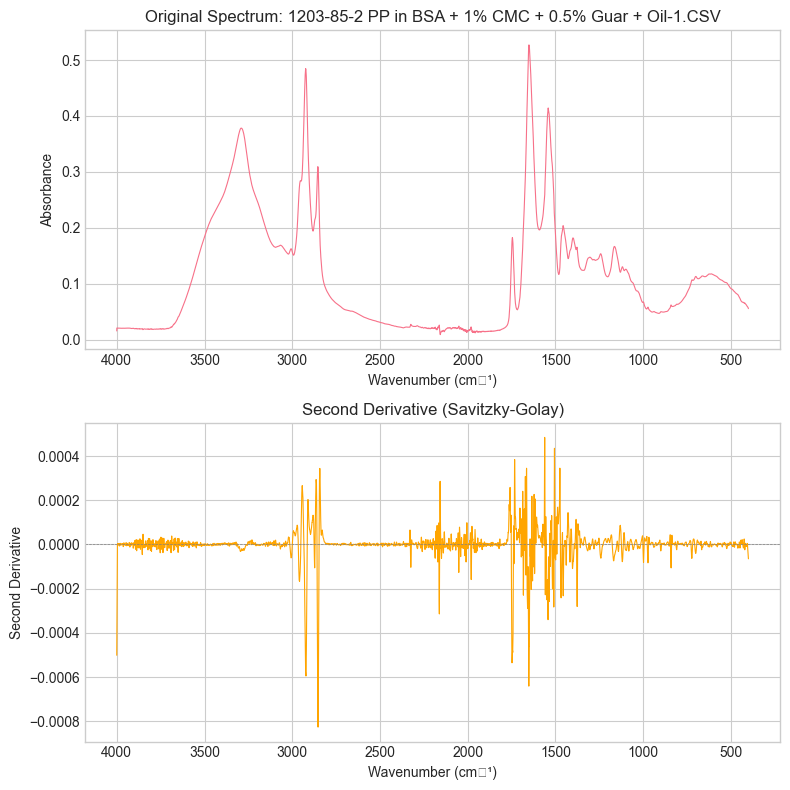

In [5]:
from scipy.signal import savgol_filter

# Apply Savitzky-Golay filter to compute second derivative of spectra
# Parameters:
#   window_length: must be odd, larger = more smoothing
#   polyorder: polynomial order for fitting
#   deriv: derivative order (2 for second derivative)

window_length = 15  # Window size for smoothing (must be odd)
polyorder = 3       # Polynomial order (must be less than window_length)

print("Applying Savitzky-Golay filter for second derivative calculation...")
print(f"  Window length: {window_length}")
print(f"  Polynomial order: {polyorder}")
print(f"  Derivative order: 2 (second derivative)")

# Compute second derivative for each spectrum
spectra_second_derivative = savgol_filter(
    spectra,
    window_length=window_length,
    polyorder=polyorder,
    deriv=2,           # Second derivative
    axis=1             # Apply along wavenumber axis
)

print(f"\nSecond derivative spectra shape: {spectra_second_derivative.shape}")
print(f"Original spectra range: [{spectra.min():.4f}, {spectra.max():.4f}]")
print(f"Second derivative range: [{spectra_second_derivative.min():.6f}, {spectra_second_derivative.max():.6f}]")

# Visualize original vs second derivative for a sample spectrum
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

sample_idx = 333
axes[0].plot(wavenumbers, spectra[sample_idx], linewidth=0.8)
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('Absorbance')
axes[0].set_title(f'Original Spectrum: {filenames[sample_idx]}')
axes[0].invert_xaxis()

axes[1].plot(wavenumbers, spectra_second_derivative[sample_idx], linewidth=0.8, color='orange')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Second Derivative')
axes[1].set_title('Second Derivative (Savitzky-Golay)')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_comparison.png', dpi=150)
plt.show()

In [6]:
# Prepare feature matrix (X) and target variables
# Using second derivative spectra as features
X = spectra_second_derivative

# Convert one-hot plastic labels to single class labels
y_plastic = np.argmax(plastic_labels, axis=1)

# Contaminant labels remain as multi-hot for multi-label classification
y_contaminant = contaminant_labels

print(f"Feature matrix X shape: {X.shape}")
print(f"  (Using second derivative spectra as features)")
print(f"Plastic type labels y_plastic shape: {y_plastic.shape}")
print(f"Contaminant labels y_contaminant shape: {y_contaminant.shape}")

# Show class distribution
print(f"\nPlastic type distribution:")
unique, counts = np.unique(y_plastic, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {PLASTIC_TYPES[u]}: {c} samples")

Feature matrix X shape: (788, 7469)
  (Using second derivative spectra as features)
Plastic type labels y_plastic shape: (788,)
Contaminant labels y_contaminant shape: (788, 6)

Plastic type distribution:
  PP: 172 samples
  LDPE: 188 samples
  LLDPE: 190 samples
  HDPE: 238 samples


In [7]:
# Split data into training and test sets
# Use a single split to ensure plastic and contaminant labels stay aligned
X_train, X_test, y_plastic_train, y_plastic_test, y_contaminant_train, y_contaminant_test = train_test_split(
    X, y_plastic, y_contaminant,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_plastic
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 630 samples
Test set: 158 samples


In [8]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")

Scaled training data mean: -0.000000
Scaled training data std: 1.000000


## 2.1 Principal Component Analysis (PCA)

PRINCIPAL COMPONENT ANALYSIS (PCA)

Total features (wavenumber points): 7469

Explained variance by top components:
  PC1: 18.11% (cumulative: 18.11%)
  PC2: 10.80% (cumulative: 28.91%)
  PC3: 9.13% (cumulative: 38.04%)
  PC4: 6.43% (cumulative: 44.47%)
  PC5: 4.92% (cumulative: 49.39%)
  PC6: 3.84% (cumulative: 53.23%)
  PC7: 1.65% (cumulative: 54.88%)
  PC8: 1.52% (cumulative: 56.40%)
  PC9: 1.28% (cumulative: 57.68%)
  PC10: 1.22% (cumulative: 58.90%)

Components needed for 95% variance: 168
Components needed for 99% variance: 281


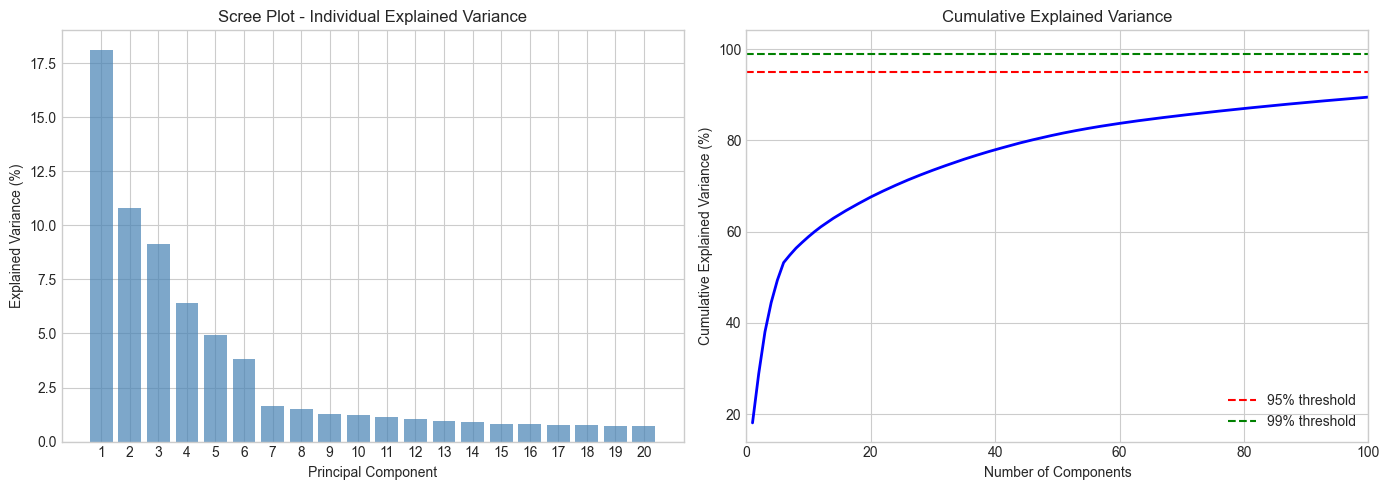

In [9]:
from sklearn.decomposition import PCA

# Perform PCA on the full scaled dataset
# First, scale all data (not just training)
X_all_scaled = scaler.fit_transform(X)

# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_all_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components needed for different variance thresholds
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("=" * 60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 60)
print(f"\nTotal features (wavenumber points): {X.shape[1]}")
print(f"\nExplained variance by top components:")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumulative_variance[i]*100:.2f}%)")

print(f"\nComponents needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scree plot (individual variance)
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot - Individual Explained Variance')
axes[0].set_xticks(range(1, 21))

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'b-', linewidth=2)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=99, color='g', linestyle='--', label='99% threshold')
axes[1].axvline(x=n_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_99, color='g', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xlim([0, min(100, len(cumulative_variance))])

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_pca_variance.png', dpi=150)
plt.show()

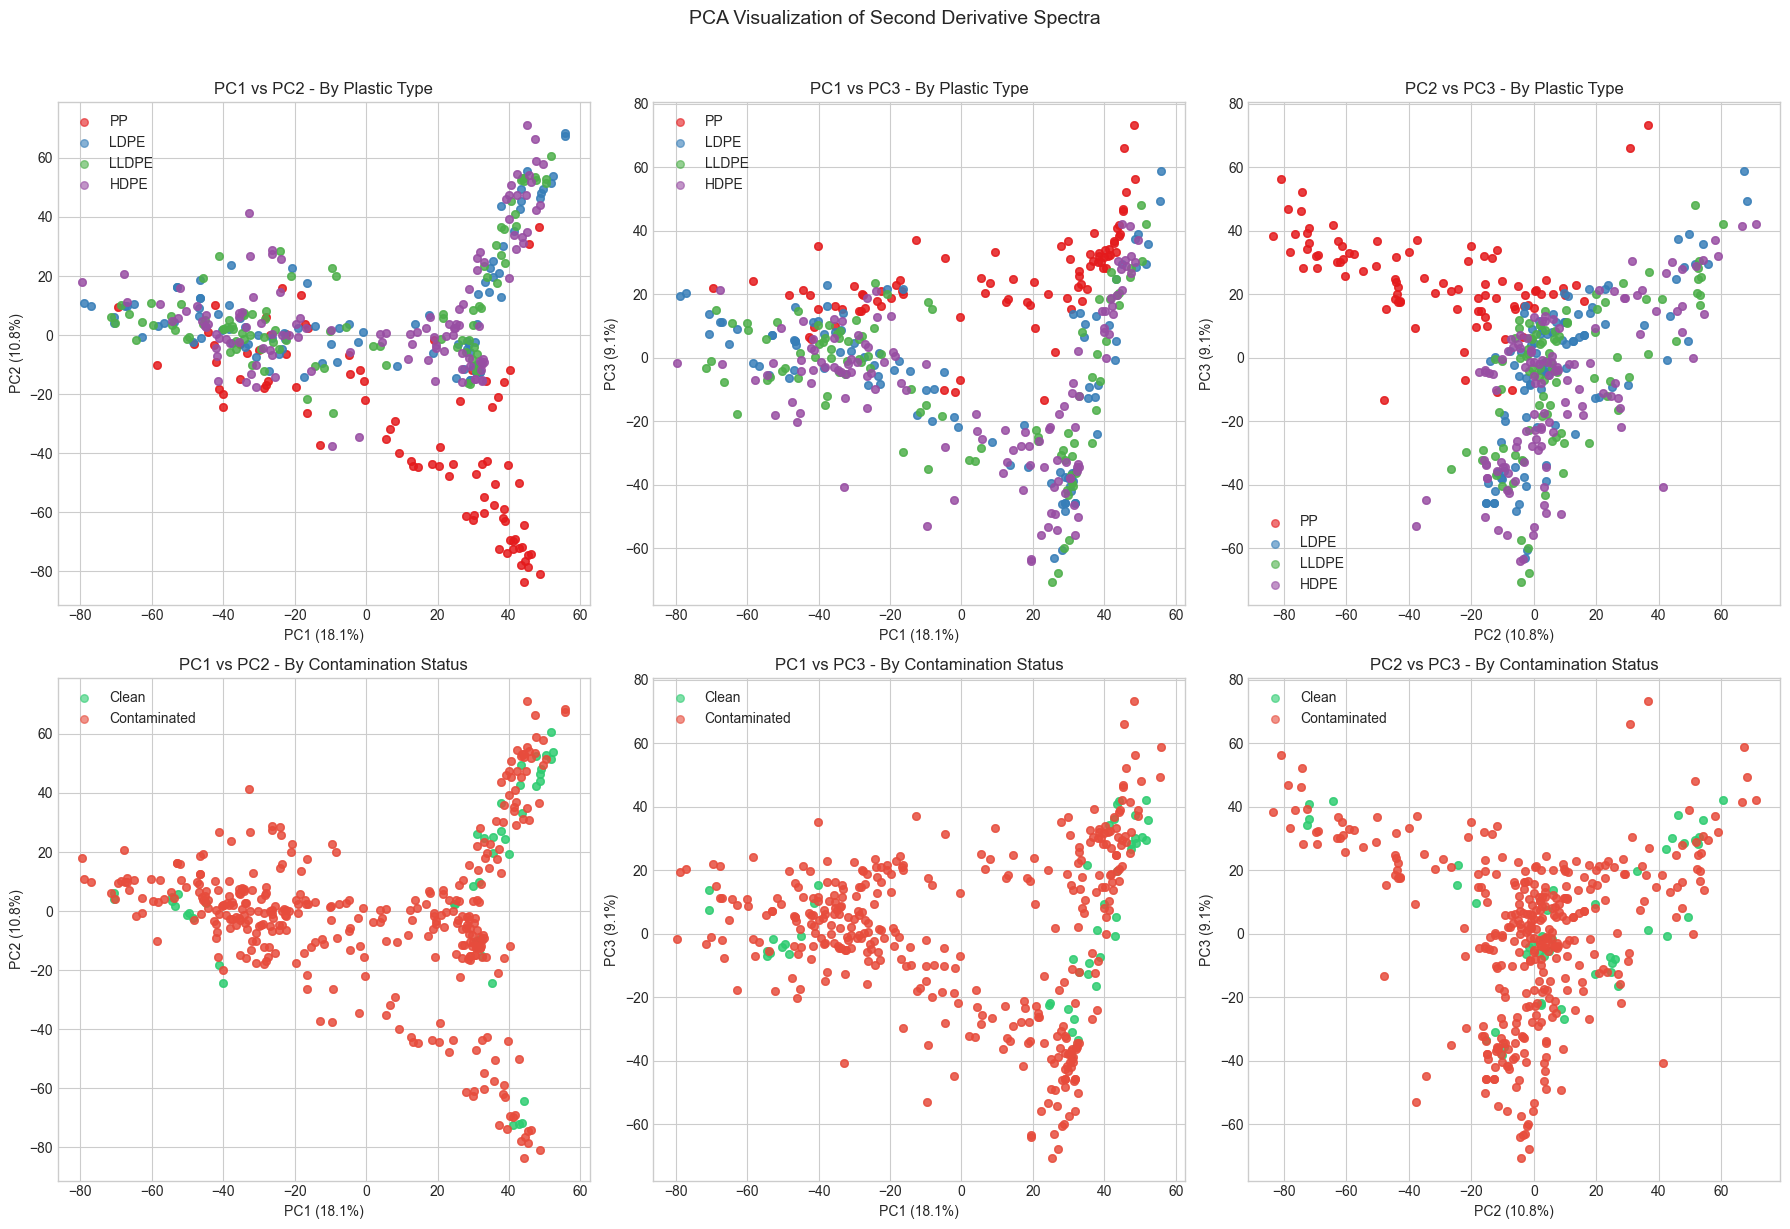


PCA Summary:
  Clean samples: 90
  Contaminated samples: 698


In [10]:
# Visualize data in PCA space (first 2-3 components)
# Transform data to PCA space
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(X_all_scaled)

# Create scatter plots colored by plastic type and contaminants
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: PC1 vs PC2, PC1 vs PC3, PC2 vs PC3 - colored by plastic type
colors_plastic = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  # Red, Blue, Green, Purple
for i, plastic in enumerate(PLASTIC_TYPES):
    mask = y_plastic == i
    axes[0, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)
    axes[0, 1].scatter(X_pca[mask, 0], X_pca[mask, 2], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)
    axes[0, 2].scatter(X_pca[mask, 1], X_pca[mask, 2], c=colors_plastic[i], 
                       label=plastic, alpha=0.6, s=30)

axes[0, 0].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 0].set_title('PC1 vs PC2 - By Plastic Type')
axes[0, 0].legend()

axes[0, 1].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[0, 1].set_title('PC1 vs PC3 - By Plastic Type')
axes[0, 1].legend()

axes[0, 2].set_xlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 2].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[0, 2].set_title('PC2 vs PC3 - By Plastic Type')
axes[0, 2].legend()

# Row 2: Colored by contamination status (clean vs contaminated)
has_contaminant = y_contaminant.sum(axis=1) > 0
colors_contam = ['#2ecc71', '#e74c3c']  # Green for clean, Red for contaminated
labels_contam = ['Clean', 'Contaminated']

for i, (has_cont, label) in enumerate(zip([False, True], labels_contam)):
    mask = has_contaminant == has_cont
    axes[1, 0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)
    axes[1, 1].scatter(X_pca[mask, 0], X_pca[mask, 2], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)
    axes[1, 2].scatter(X_pca[mask, 1], X_pca[mask, 2], c=colors_contam[i], 
                       label=label, alpha=0.6, s=30)

axes[1, 0].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 0].set_title('PC1 vs PC2 - By Contamination Status')
axes[1, 0].legend()

axes[1, 1].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC3 - By Contamination Status')
axes[1, 1].legend()

axes[1, 2].set_xlabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 2].set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
axes[1, 2].set_title('PC2 vs PC3 - By Contamination Status')
axes[1, 2].legend()

plt.suptitle('PCA Visualization of Second Derivative Spectra', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_pca_scatter.png', dpi=150)
plt.show()

print(f"\nPCA Summary:")
print(f"  Clean samples: {(~has_contaminant).sum()}")
print(f"  Contaminated samples: {has_contaminant.sum()}")

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\1861768182.py:27: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\1861768182.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_pca_loadings.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


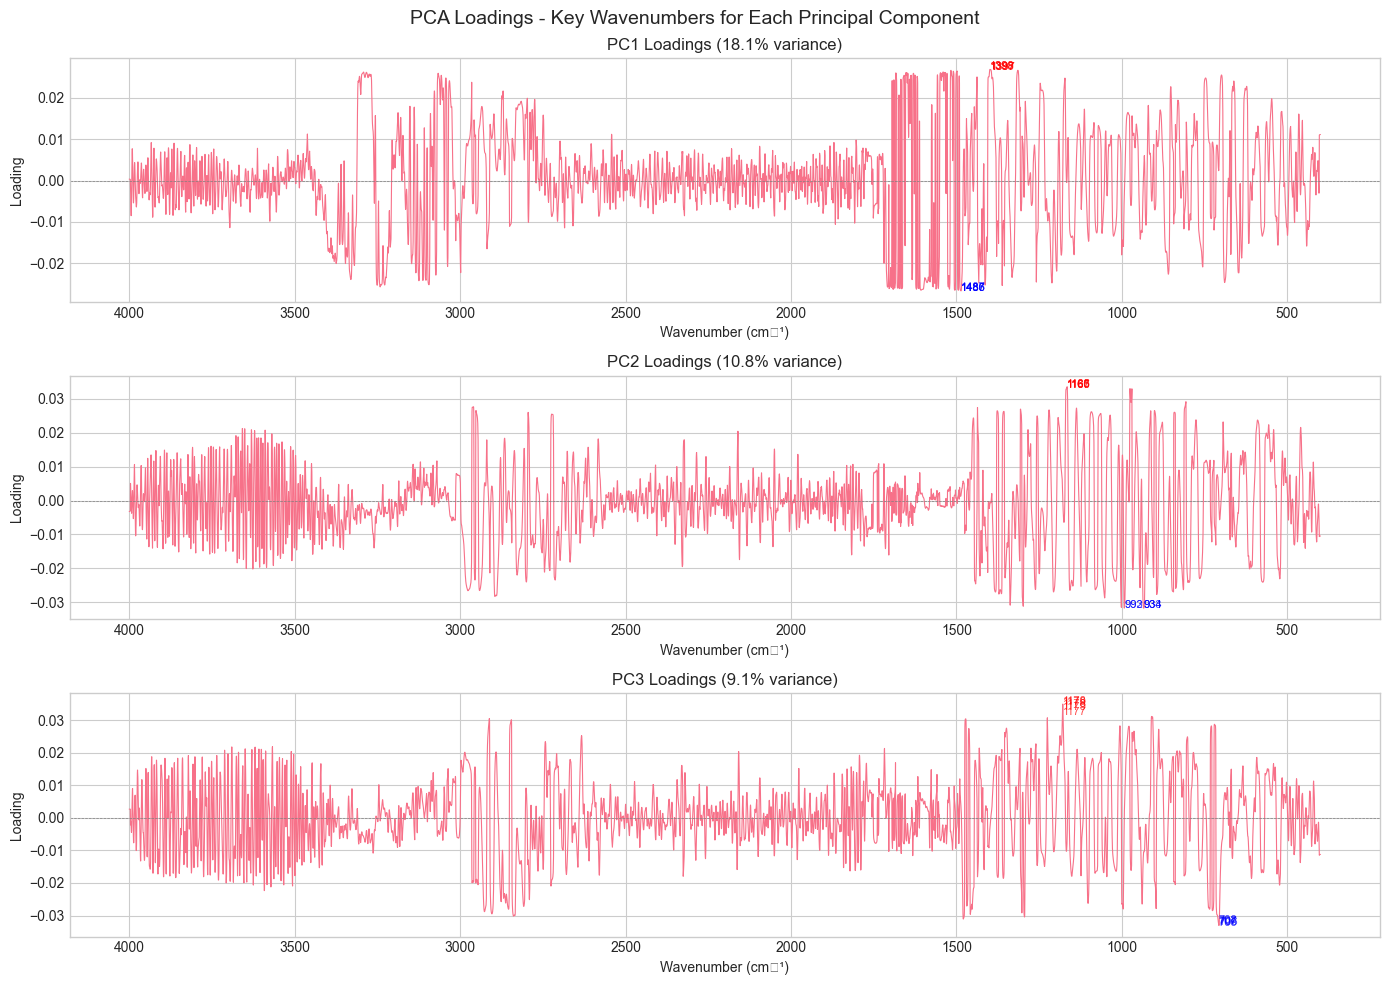


TOP CONTRIBUTING WAVENUMBERS BY PRINCIPAL COMPONENT

PC1 (18.1% variance):
----------------------------------------
   1.  1398.6 cm⁻¹ (+0.0269)
   2.  1398.2 cm⁻¹ (+0.0269)
   3.  1397.7 cm⁻¹ (+0.0269)
   4.  1397.2 cm⁻¹ (+0.0268)
   5.  1396.7 cm⁻¹ (+0.0268)
   6.  1396.2 cm⁻¹ (+0.0268)
   7.  1399.1 cm⁻¹ (+0.0268)
   8.  1395.8 cm⁻¹ (+0.0268)
   9.  1395.3 cm⁻¹ (+0.0267)
  10.  1485.9 cm⁻¹ (-0.0267)

PC2 (10.8% variance):
----------------------------------------
   1.  1165.3 cm⁻¹ (+0.0335)
   2.  1165.8 cm⁻¹ (+0.0334)
   3.  1164.8 cm⁻¹ (+0.0333)
   4.  1166.3 cm⁻¹ (+0.0332)
   5.  1166.7 cm⁻¹ (+0.0331)
   6.   975.3 cm⁻¹ (+0.0330)
   7.  1167.2 cm⁻¹ (+0.0329)
   8.   969.6 cm⁻¹ (+0.0329)
   9.  1168.2 cm⁻¹ (+0.0329)
  10.  1167.7 cm⁻¹ (+0.0329)

PC3 (9.1% variance):
----------------------------------------
   1.  1178.3 cm⁻¹ (+0.0349)
   2.  1178.8 cm⁻¹ (+0.0347)
   3.  1177.8 cm⁻¹ (+0.0339)
   4.   706.3 cm⁻¹ (-0.0331)
   5.  1179.3 cm⁻¹ (+0.0330)
   6.   706.8 cm⁻¹ (-0.0330)
  

In [11]:
# Visualize PCA loadings (which wavenumbers contribute most to each PC)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, ax in enumerate(axes):
    loadings = pca_3d.components_[i]
    ax.plot(wavenumbers, loadings, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Loading')
    ax.set_title(f'PC{i+1} Loadings ({pca_3d.explained_variance_ratio_[i]*100:.1f}% variance)')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()
    
    # Mark top 5 positive and negative loadings
    top_pos_idx = np.argsort(loadings)[-5:]
    top_neg_idx = np.argsort(loadings)[:5]
    
    for idx in top_pos_idx:
        ax.annotate(f'{wavenumbers[idx]:.0f}', 
                   xy=(wavenumbers[idx], loadings[idx]),
                   fontsize=8, color='red', alpha=0.7)
    for idx in top_neg_idx:
        ax.annotate(f'{wavenumbers[idx]:.0f}', 
                   xy=(wavenumbers[idx], loadings[idx]),
                   fontsize=8, color='blue', alpha=0.7)

plt.suptitle('PCA Loadings - Key Wavenumbers for Each Principal Component', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_pca_loadings.png', dpi=150)
plt.show()

# Print top contributing wavenumbers for each PC
print("\n" + "=" * 60)
print("TOP CONTRIBUTING WAVENUMBERS BY PRINCIPAL COMPONENT")
print("=" * 60)

for i in range(3):
    loadings = pca_3d.components_[i]
    top_idx = np.argsort(np.abs(loadings))[-10:][::-1]
    
    print(f"\nPC{i+1} ({pca_3d.explained_variance_ratio_[i]*100:.1f}% variance):")
    print("-" * 40)
    for rank, idx in enumerate(top_idx, 1):
        direction = "+" if loadings[idx] > 0 else "-"
        print(f"  {rank:2d}. {wavenumbers[idx]:7.1f} cm⁻¹ ({direction}{abs(loadings[idx]):.4f})")

## 3. Logistic Regression for Plastic Type Classification

In [12]:
# Create and train logistic regression model for plastic type
lr_plastic = LogisticRegression(
    multi_class='multinomial',
    solver='newton-cg',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=10.0  # Regularization strength
)

print("Training Logistic Regression for Plastic Type Classification...")
lr_plastic.fit(X_train_scaled, y_plastic_train)
print("Training complete!")

Training Logistic Regression for Plastic Type Classification...


c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete!


In [13]:
# Predictions on test set
y_plastic_pred = lr_plastic.predict(X_test_scaled)

# Evaluate plastic type classification
print("=" * 60)
print("PLASTIC TYPE CLASSIFICATION RESULTS")
print("=" * 60)

# Accuracy
accuracy_plastic = accuracy_score(y_plastic_test, y_plastic_pred)
print(f"\nAccuracy: {accuracy_plastic:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES))

PLASTIC TYPE CLASSIFICATION RESULTS

Accuracy: 0.9114

Classification Report:
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       1.00      0.68      0.81        38
       LLDPE       0.82      0.95      0.88        38
        HDPE       0.89      1.00      0.94        48

    accuracy                           0.91       158
   macro avg       0.93      0.91      0.91       158
weighted avg       0.92      0.91      0.91       158



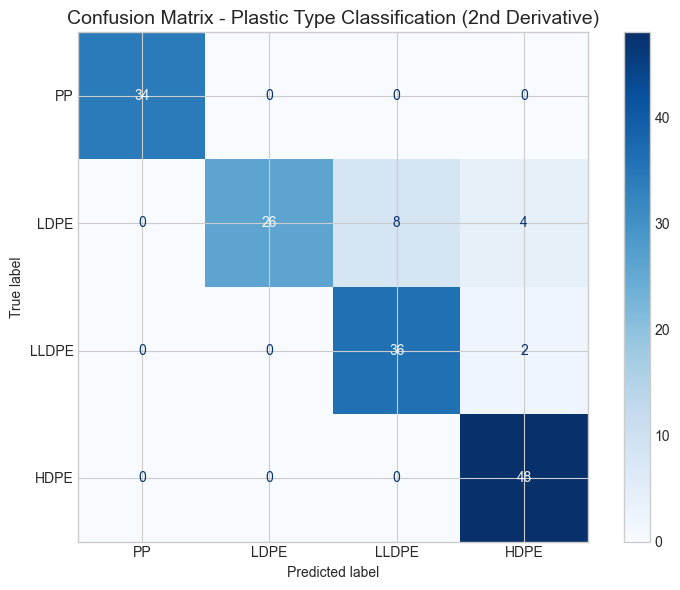

In [14]:
# Confusion matrix for plastic type
cm_plastic = confusion_matrix(y_plastic_test, y_plastic_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_plastic, display_labels=PLASTIC_TYPES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix - Plastic Type Classification (2nd Derivative)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_plastic_confusion_matrix.png', dpi=150)
plt.show()

In [15]:
# Cross-validation for plastic type model
print("Performing 5-fold Cross-Validation for Plastic Type Model...")
cv_scores_plastic = cross_val_score(
    lr_plastic, 
    X_train_scaled, 
    y_plastic_train, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\nCross-validation scores: {cv_scores_plastic}")
print(f"Mean CV accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})")

Performing 5-fold Cross-Validation for Plastic Type Model...


c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning


Cross-validation scores: [0.92857143 0.8968254  0.95238095 0.92063492 0.92857143]
Mean CV accuracy: 0.9254 (+/- 0.0356)


## 4. Logistic Regression for Contaminant Detection (Multi-Label)

In [16]:
# Create multi-output logistic regression for contaminant detection
# Using MultiOutputClassifier wrapper for multi-label classification
base_lr = LogisticRegression(
    solver='newton-cg',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=10.0  # Regularization strength
)

lr_contaminant = MultiOutputClassifier(base_lr, n_jobs=1)

print("Training Multi-Output Logistic Regression for Contaminant Detection...")
lr_contaminant.fit(X_train_scaled, y_contaminant_train)
print("Training complete!")

Training Multi-Output Logistic Regression for Contaminant Detection...


Training complete!


In [17]:
# Predictions on test set
y_contaminant_pred = lr_contaminant.predict(X_test_scaled)

# Evaluate contaminant detection
print("=" * 60)
print("CONTAMINANT DETECTION RESULTS (Multi-Label)")
print("=" * 60)

# Hamming loss (fraction of incorrectly predicted labels)
h_loss = hamming_loss(y_contaminant_test, y_contaminant_pred)
print(f"\nHamming Loss: {h_loss:.4f}")

# Exact match ratio (subset accuracy)
exact_match = accuracy_score(y_contaminant_test, y_contaminant_pred)
print(f"Exact Match Ratio (Subset Accuracy): {exact_match:.4f}")

# Per-label metrics
print("\nPer-Contaminant Performance:")
print("-" * 50)
for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    print(f"{contaminant:10s}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

CONTAMINANT DETECTION RESULTS (Multi-Label)

Hamming Loss: 0.0063
Exact Match Ratio (Subset Accuracy): 0.9873

Per-Contaminant Performance:
--------------------------------------------------
BSA       : Accuracy = 1.0000, F1-Score = 1.0000
Oil       : Accuracy = 0.9873, F1-Score = 0.9884
Starch    : Accuracy = 0.9873, F1-Score = 0.9861
CMC       : Accuracy = 0.9873, F1-Score = 0.9831
Guar      : Accuracy = 1.0000, F1-Score = 1.0000
Casein    : Accuracy = 1.0000, F1-Score = 1.0000


Performing 5-fold Cross-Validation for Contaminant Detection Model...

OVERALL CROSS-VALIDATION METRICS (Multi-Label)
CV Hamming Loss: 0.0103
CV Exact Match Ratio (Subset Accuracy): 0.9651

Cross-Validation Results (5-fold) - Per Contaminant:
----------------------------------------------------------------------
Contaminant    Mean Accuracy        Std      Mean F1        Std
----------------------------------------------------------------------
BSA                   0.9937     0.0059       0.9937     0.0059
Oil                   0.9937     0.0059       0.9941     0.0055
Starch                0.9873     0.0108       0.9864     0.0113
CMC                   0.9810     0.0095       0.9770     0.0115
Guar                  0.9873     0.0108       0.9874     0.0107
Casein                0.9905     0.0190       0.9250     0.1500
----------------------------------------------------------------------
Overall               0.9889     0.0121       0.9773     0.0663


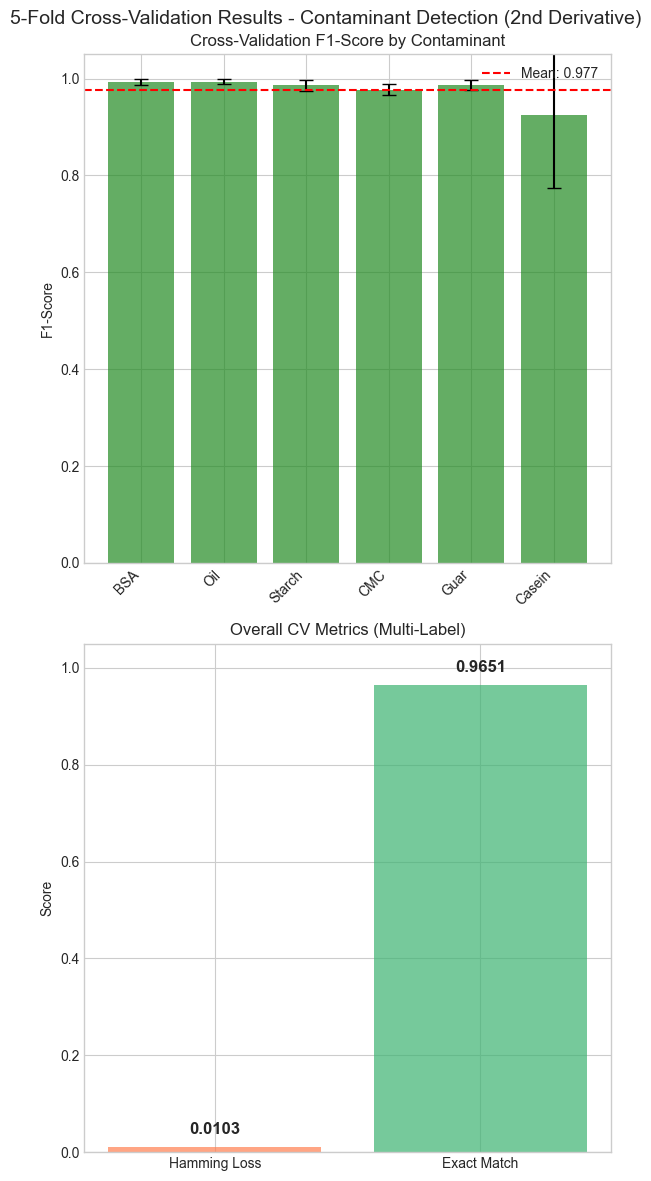

In [18]:
# Cross-validation for contaminant detection model (Multi-Label)
from sklearn.model_selection import cross_val_predict, KFold

print("Performing 5-fold Cross-Validation for Contaminant Detection Model...")

# Create a fresh model for cross-validation
base_lr_cv = LogisticRegression(
    solver='newton-cg',
    max_iter=5000,
    random_state=RANDOM_STATE+1,
    C=100.0
)
lr_contaminant_cv = MultiOutputClassifier(base_lr_cv, n_jobs=-1)

# ============================================================================
# Overall Hamming Loss via Cross-Validation
# ============================================================================
# Use cross_val_predict to get out-of-fold predictions for the full multi-label model
cv_folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_contaminant_cv_pred = cross_val_predict(
    lr_contaminant_cv,
    X_train_scaled,
    y_contaminant_train,
    cv=cv_folds
)

# Calculate overall CV Hamming loss
cv_hamming_loss = hamming_loss(y_contaminant_train, y_contaminant_cv_pred)
cv_exact_match = accuracy_score(y_contaminant_train, y_contaminant_cv_pred)

print("\n" + "=" * 70)
print("OVERALL CROSS-VALIDATION METRICS (Multi-Label)")
print("=" * 70)
print(f"CV Hamming Loss: {cv_hamming_loss:.4f}")
print(f"CV Exact Match Ratio (Subset Accuracy): {cv_exact_match:.4f}")

# ============================================================================
# Per-Contaminant CV Scores
# ============================================================================
# We'll compute CV scores for each contaminant separately and aggregate
cv_scores_per_contaminant = []
cv_f1_per_contaminant = []

for i, contaminant in enumerate(CONTAMINANTS):
    # Create single-output model for this contaminant
    lr_single = LogisticRegression(
        solver='newton-cg',
        max_iter=5000,
        random_state=RANDOM_STATE,
        C=100.0
    )
    
    # Cross-validation scores for accuracy
    cv_acc = cross_val_score(
        lr_single, 
        X_train_scaled, 
        y_contaminant_train[:, i], 
        cv=5,
        scoring='accuracy'
    )
    
    # Cross-validation scores for F1
    cv_f1 = cross_val_score(
        lr_single, 
        X_train_scaled, 
        y_contaminant_train[:, i], 
        cv=5,
        scoring='f1'
    )
    
    cv_scores_per_contaminant.append(cv_acc)
    cv_f1_per_contaminant.append(cv_f1)

# Display results
print("\nCross-Validation Results (5-fold) - Per Contaminant:")
print("-" * 70)
print(f"{'Contaminant':<12} {'Mean Accuracy':>15} {'Std':>10} {'Mean F1':>12} {'Std':>10}")
print("-" * 70)

for i, contaminant in enumerate(CONTAMINANTS):
    acc_mean = cv_scores_per_contaminant[i].mean()
    acc_std = cv_scores_per_contaminant[i].std()
    f1_mean = cv_f1_per_contaminant[i].mean()
    f1_std = cv_f1_per_contaminant[i].std()
    print(f"{contaminant:<12} {acc_mean:>15.4f} {acc_std:>10.4f} {f1_mean:>12.4f} {f1_std:>10.4f}")

# Overall statistics
all_acc = np.array(cv_scores_per_contaminant)
all_f1 = np.array(cv_f1_per_contaminant)
print("-" * 70)
print(f"{'Overall':<12} {all_acc.mean():>15.4f} {all_acc.std():>10.4f} {all_f1.mean():>12.4f} {all_f1.std():>10.4f}")

# Visualize CV results
fig, axes = plt.subplots(2, 1, figsize=(6, 12))


# Plot 1: Accuracy CV scores

x_pos = np.arange(len(CONTAMINANTS))
acc_means = [cv.mean() for cv in cv_scores_per_contaminant]
acc_stds = [cv.std() for cv in cv_scores_per_contaminant]

"""

axes[0].bar(x_pos, acc_means, yerr=acc_stds, capsize=5, color='steelblue', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CONTAMINANTS, rotation=45, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Cross-Validation Accuracy by Contaminant')
axes[0].set_ylim([0, 1.05])
axes[0].axhline(y=np.mean(acc_means), color='red', linestyle='--', label=f'Mean: {np.mean(acc_means):.3f}')
axes[0].legend()

"""


# Plot 2: F1 CV scores
f1_means = [cv.mean() for cv in cv_f1_per_contaminant]
f1_stds = [cv.std() for cv in cv_f1_per_contaminant]

axes[0].bar(x_pos, f1_means, yerr=f1_stds, capsize=5, color='forestgreen', alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CONTAMINANTS, rotation=45, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Cross-Validation F1-Score by Contaminant')
axes[0].set_ylim([0, 1.05])
axes[0].axhline(y=np.mean(f1_means), color='red', linestyle='--', label=f'Mean: {np.mean(f1_means):.3f}')
axes[0].legend()

# Plot 3: Overall metrics summary
metrics_names = ['Hamming Loss', 'Exact Match']
metrics_values = [cv_hamming_loss, cv_exact_match]
colors = ['coral', 'mediumseagreen']

bars = axes[1].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_title('Overall CV Metrics (Multi-Label)')
axes[1].set_ylim([0, 1.05])

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('5-Fold Cross-Validation Results - Contaminant Detection (2nd Derivative)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_contaminant_cv_results.png', dpi=150)
plt.show()



In [19]:



# ============================================================================
# Export CV Metrics to Excel (.xlsx)
# ============================================================================
from datetime import datetime

# Define output directory for reports
reports_dir = project_root / 'reports' / 'text_reports'
reports_dir.mkdir(parents=True, exist_ok=True)

# Create DataFrames for CV metrics
# 1. Per-contaminant metrics
per_contaminant_data = {
    'Contaminant': CONTAMINANTS,
    'Mean Accuracy': [cv.mean()*100 for cv in cv_scores_per_contaminant],
    'Std Accuracy': [cv.std()*100 for cv in cv_scores_per_contaminant],
    'Mean F1': [cv.mean()*100 for cv in cv_f1_per_contaminant],
    'Std F1': [cv.std()*100 for cv in cv_f1_per_contaminant]
}
df_per_contaminant = pd.DataFrame(per_contaminant_data)

# Add overall row
overall_row = pd.DataFrame({
    'Contaminant': ['Overall'],
    'Mean Accuracy': [all_acc.mean()*100],
    'Std Accuracy': [all_acc.std()*100],
    'Mean F1': [all_f1.mean()*100],
    'Std F1': [all_f1.std()*100]
})
df_per_contaminant = pd.concat([df_per_contaminant, overall_row], ignore_index=True)

# 2. Overall multi-label metrics
overall_metrics_data = {
    'Metric': ['Hamming Loss (%)', 'Exact Match Ratio (%)', 'CV Folds', 'Regularization (C)', 'Solver'],
    'Value': [cv_hamming_loss * 100, cv_exact_match * 100, 5, 100.0, 'newton-cg']
}
df_overall_metrics = pd.DataFrame(overall_metrics_data)

# 3. Individual fold scores for each contaminant (as percentages)
fold_scores_data = {'Contaminant': CONTAMINANTS}
for fold in range(5):
    fold_scores_data[f'Fold {fold+1} Acc (%)'] = [cv_scores_per_contaminant[i][fold] * 100 for i in range(len(CONTAMINANTS))]
    fold_scores_data[f'Fold {fold+1} F1 (%)'] = [cv_f1_per_contaminant[i][fold] * 100 for i in range(len(CONTAMINANTS))]
df_fold_scores = pd.DataFrame(fold_scores_data)

# Save to Excel with multiple sheets
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = reports_dir / f'lr_second_derivative_cv_metrics.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_overall_metrics.to_excel(writer, sheet_name='Overall Metrics', index=False)
    df_per_contaminant.to_excel(writer, sheet_name='Per-Contaminant Summary', index=False)
    df_fold_scores.to_excel(writer, sheet_name='Individual Fold Scores', index=False)

print(f"\nCV metrics exported to: {excel_path}")


CV metrics exported to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports\lr_second_derivative_cv_metrics.xlsx


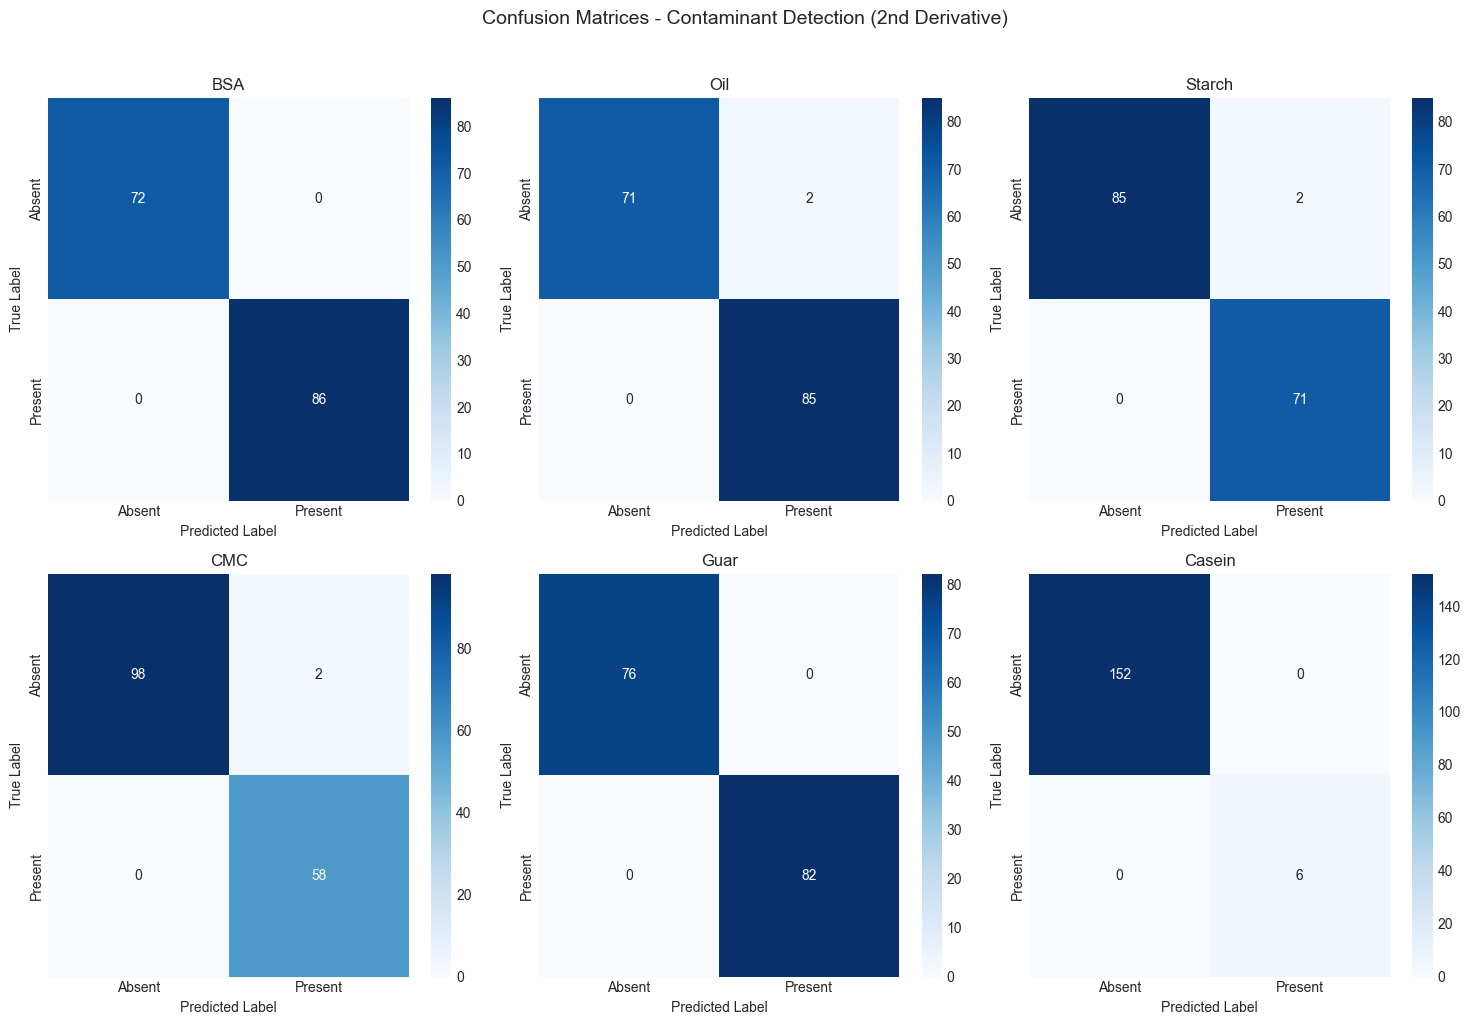

In [20]:
# Confusion matrices for each contaminant
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    cm = confusion_matrix(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'])
    ax.set_title(f'{contaminant}', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - Contaminant Detection (2nd Derivative)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_contaminant_confusion_matrices.png', dpi=150)
plt.show()

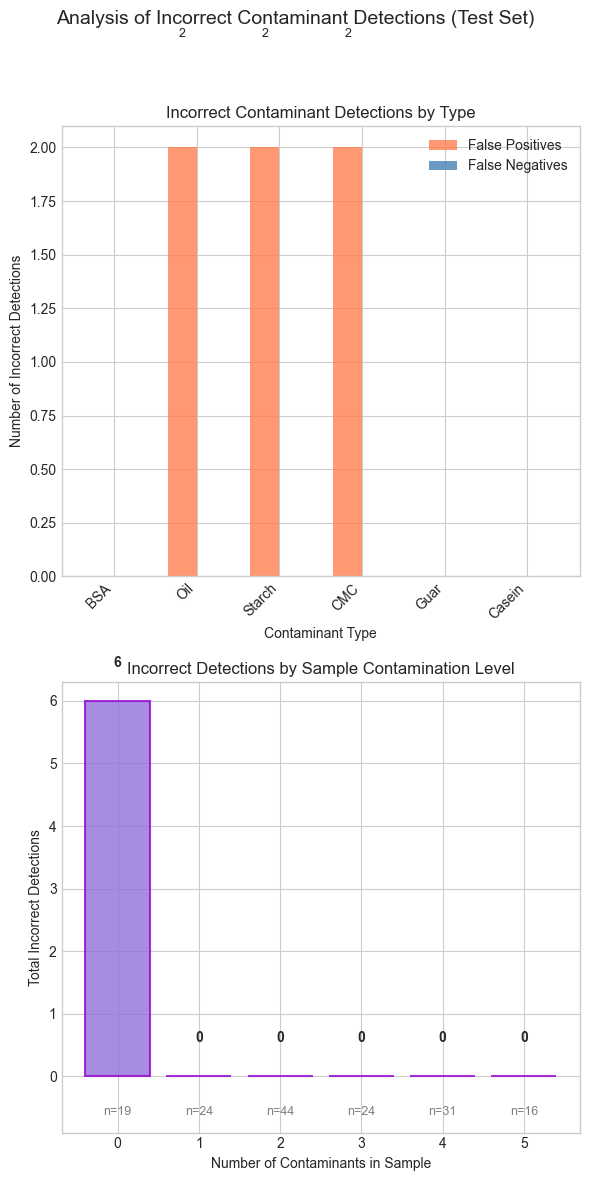

ERROR ANALYSIS SUMMARY

By Contaminant Type:
--------------------------------------------------
Contaminant     False Pos    False Neg        Total
--------------------------------------------------
BSA                     0            0            0
Oil                     2            0            2
Starch                  2            0            2
CMC                     2            0            2
Guar                    0            0            0
Casein                  0            0            0
--------------------------------------------------
TOTAL                   6            0            6


By Number of Contaminants in Sample:
--------------------------------------------------
# Contaminants     # Samples     # Errors   Errors/Sample
--------------------------------------------------
0                         19            6            0.32
1                         24            0            0.00
2                         44            0            0.00
3            

In [21]:
# Analyze incorrect contaminant detections

# Calculate errors for each contaminant
# Error types: False Positive (predicted 1, actual 0) and False Negative (predicted 0, actual 1)
false_positives = ((y_contaminant_pred == 1) & (y_contaminant_test == 0)).astype(int)
false_negatives = ((y_contaminant_pred == 0) & (y_contaminant_test == 1)).astype(int)
total_errors = (y_contaminant_pred != y_contaminant_test).astype(int)

# Count errors by contaminant type
fp_by_contaminant = false_positives.sum(axis=0)
fn_by_contaminant = false_negatives.sum(axis=0)
total_errors_by_contaminant = total_errors.sum(axis=0)

# Count number of contaminants per sample (ground truth)
n_contaminants_per_sample = y_contaminant_test.sum(axis=1)

# Count total errors per sample
errors_per_sample = total_errors.sum(axis=1)

# Group errors by number of contaminants in the sample
unique_n_contaminants = np.unique(n_contaminants_per_sample)
errors_by_n_contaminants = []
sample_counts_by_n_contaminants = []

for n in unique_n_contaminants:
    mask = n_contaminants_per_sample == n
    total_errors_for_n = errors_per_sample[mask].sum()
    sample_count = mask.sum()
    errors_by_n_contaminants.append(total_errors_for_n)
    sample_counts_by_n_contaminants.append(sample_count)

# Create visualizations
fig, axes = plt.subplots(2, 1, figsize=(6, 12))

# ============================================================================
# Plot 1: Incorrect detections by contaminant type
# ============================================================================
x_pos = np.arange(len(CONTAMINANTS))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, fp_by_contaminant, width, label='False Positives', color='coral', alpha=0.8)
bars2 = axes[0].bar(x_pos + width/2, fn_by_contaminant, width, label='False Negatives', color='steelblue', alpha=0.8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CONTAMINANTS, rotation=45, ha='right')
axes[0].set_xlabel('Contaminant Type')
axes[0].set_ylabel('Number of Incorrect Detections')
axes[0].set_title('Incorrect Contaminant Detections by Type')
axes[0].legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}', 
                    ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}', 
                    ha='center', va='bottom', fontsize=9)

# ============================================================================
# Plot 2: Incorrect detections by number of contaminants in sample
# ============================================================================
x_pos2 = np.arange(len(unique_n_contaminants))

# Create bars with sample count as secondary info
bars3 = axes[1].bar(x_pos2, errors_by_n_contaminants, color='mediumpurple', alpha=0.8, 
                    edgecolor='darkviolet', linewidth=1.5)

axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels([f'{int(n)}' for n in unique_n_contaminants])
axes[1].set_xlabel('Number of Contaminants in Sample')
axes[1].set_ylabel('Total Incorrect Detections')
axes[1].set_title('Incorrect Detections by Sample Contamination Level')

# Add value labels and sample counts
for i, (bar, n_samples) in enumerate(zip(bars3, sample_counts_by_n_contaminants)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].text(bar.get_x() + bar.get_width()/2, -max(errors_by_n_contaminants)*0.08, 
                f'n={n_samples}', ha='center', va='top', fontsize=9, color='gray')

axes[1].set_ylim(bottom=-max(errors_by_n_contaminants)*0.15)

plt.suptitle('Analysis of Incorrect Contaminant Detections (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_error_analysis.png', dpi=150)
plt.show()

# Print summary statistics
print("=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)
print("\nBy Contaminant Type:")
print("-" * 50)
print(f"{'Contaminant':<12} {'False Pos':>12} {'False Neg':>12} {'Total':>12}")
print("-" * 50)
for i, cont in enumerate(CONTAMINANTS):
    print(f"{cont:<12} {fp_by_contaminant[i]:>12} {fn_by_contaminant[i]:>12} {total_errors_by_contaminant[i]:>12}")
print("-" * 50)
print(f"{'TOTAL':<12} {fp_by_contaminant.sum():>12} {fn_by_contaminant.sum():>12} {total_errors_by_contaminant.sum():>12}")

print("\n\nBy Number of Contaminants in Sample:")
print("-" * 50)
print(f"{'# Contaminants':<15} {'# Samples':>12} {'# Errors':>12} {'Errors/Sample':>15}")
print("-" * 50)
for n, n_samples, n_errors in zip(unique_n_contaminants, sample_counts_by_n_contaminants, errors_by_n_contaminants):
    avg_errors = n_errors / n_samples if n_samples > 0 else 0
    print(f"{int(n):<15} {n_samples:>12} {n_errors:>12} {avg_errors:>15.2f}")

c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


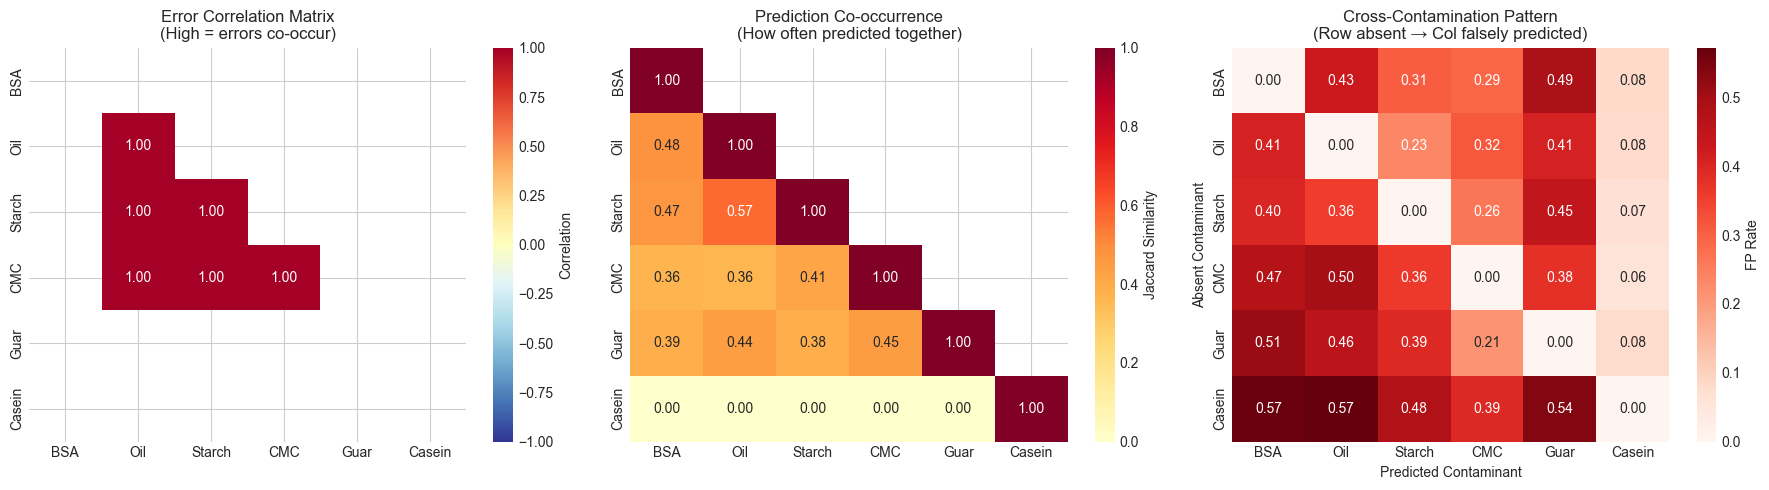


Most correlated error pairs (contaminants often misclassified together):
------------------------------------------------------------
  Oil <-> Starch: correlation = 1.000
  Oil <-> CMC: correlation = 1.000
  Starch <-> CMC: correlation = 1.000


In [22]:
# Analyze which contaminants are difficult to differentiate from each other
# Using pairwise error correlation and prediction similarity

# 1. Compute error vectors (1 = incorrect prediction, 0 = correct)
errors = (y_contaminant_test != y_contaminant_pred).astype(int)

# 2. Compute pairwise error correlation matrix
# High correlation means when one contaminant is misclassified, the other often is too
error_corr = np.corrcoef(errors.T)

# 3. Compute prediction similarity matrix (Jaccard similarity of predicted labels)
pred_similarity = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        # How often are both predicted as present together vs. at least one present
        both_present = np.sum((y_contaminant_pred[:, i] == 1) & (y_contaminant_pred[:, j] == 1))
        either_present = np.sum((y_contaminant_pred[:, i] == 1) | (y_contaminant_pred[:, j] == 1))
        pred_similarity[i, j] = both_present / either_present if either_present > 0 else 0

# 4. Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Error correlation matrix
mask1 = np.triu(np.ones_like(error_corr, dtype=bool), k=1)
sns.heatmap(error_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[0], vmin=-1, vmax=1, mask=mask1,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Error Correlation Matrix\n(High = errors co-occur)', fontsize=12)

# Plot 2: Prediction similarity (Jaccard)
mask2 = np.triu(np.ones_like(pred_similarity, dtype=bool), k=1)
sns.heatmap(pred_similarity, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[1], vmin=0, vmax=1, mask=mask2,
            cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Prediction Co-occurrence\n(How often predicted together)', fontsize=12)

# Plot 3: Confusion pattern - False positive rates when each contaminant is truly absent
fp_when_absent = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        if i != j:
            # When contaminant i is truly absent, how often is j falsely predicted?
            i_absent = y_contaminant_test[:, i] == 0
            if np.sum(i_absent) > 0:
                fp_when_absent[i, j] = np.mean(y_contaminant_pred[i_absent, j])

sns.heatmap(fp_when_absent, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[2], vmin=0,
            cbar_kws={'label': 'FP Rate'})
axes[2].set_title('Cross-Contamination Pattern\n(Row absent → Col falsely predicted)', fontsize=12)
axes[2].set_xlabel('Predicted Contaminant')
axes[2].set_ylabel('Absent Contaminant')

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_contaminant_confusion_analysis.png', dpi=150)
plt.show()

# Print summary of most confused pairs
print("\nMost correlated error pairs (contaminants often misclassified together):")
print("-" * 60)
error_pairs = []
for i in range(len(CONTAMINANTS)):
    for j in range(i+1, len(CONTAMINANTS)):
        if not np.isnan(error_corr[i, j]):
            error_pairs.append((CONTAMINANTS[i], CONTAMINANTS[j], error_corr[i, j]))

error_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, corr in error_pairs[:5]:
    print(f"  {c1} <-> {c2}: correlation = {corr:.3f}")

## 4.1 Hyperparameter Tuning with Grid Search

In [23]:
from sklearn.model_selection import GridSearchCV

# ============================================================================
# Grid Search for Plastic Type Classification Model
# ============================================================================




print("=" * 60)
print("GRID SEARCH: Plastic Type Classification")
print("=" * 60)

# Define parameter grid for plastic type model
param_grid_plastic = {
    'C': [0.1, 1.0, 10.0, 100.0, 1000.0],
    'solver': ['newton-cg', 'lbfgs'],
    'penalty': ['l2'],
    'max_iter': [5000]
}

# Create base model
lr_plastic_base = LogisticRegression(
    multi_class='multinomial',
    random_state=RANDOM_STATE
)

# Run grid search
grid_search_plastic = GridSearchCV(
    lr_plastic_base,
    param_grid_plastic,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nSearching for best parameters...")
grid_search_plastic.fit(X_train_scaled, y_plastic_train)


print(f"\nBest parameters: {grid_search_plastic.best_params_}")

print(f"Best CV accuracy: {grid_search_plastic.best_score_:.4f}")



# Evaluate best model on test set
best_lr_plastic = grid_search_plastic.best_estimator_
y_plastic_pred_tuned = best_lr_plastic.predict(X_test_scaled)
accuracy_plastic_tuned = accuracy_score(y_plastic_test, y_plastic_pred_tuned)

print(f"Test accuracy with tuned model: {accuracy_plastic_tuned:.4f}")
print(f"Improvement over default: {(accuracy_plastic_tuned - accuracy_plastic)*100:+.2f}%")

GRID SEARCH: Plastic Type Classification

Searching for best parameters...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best parameters: {'C': 1.0, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV accuracy: 0.9286
Test accuracy with tuned model: 0.9114
Improvement over default: +0.00%


In [24]:
# ============================================================================
# Grid Search for Contaminant Detection Model (Multi-Label)
# ============================================================================



print("=" * 60)
print("GRID SEARCH: Contaminant Detection (Multi-Label)")
print("=" * 60)

# Define parameter grid for contaminant model
# For MultiOutputClassifier, parameters are prefixed with 'estimator__'
param_grid_contaminant = {
    'estimator__C': [0.1, 1.0, 10.0, 100.0, 1000.0],
    'estimator__solver': ['newton-cg', 'lbfgs'],
    'estimator__penalty': ['l2'],
    'estimator__max_iter': [5000]
}

# Create base multi-output model
base_lr_contaminant = LogisticRegression(random_state=RANDOM_STATE)
lr_contaminant_multi = MultiOutputClassifier(base_lr_contaminant)

# Run grid search (using hamming loss as negative for minimization)
# We'll use a custom scorer based on accuracy for multi-label
from sklearn.metrics import make_scorer

def multi_label_accuracy(y_true, y_pred):
    #Calculate average accuracy across all labels.
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

multi_label_scorer = make_scorer(multi_label_accuracy)

grid_search_contaminant = GridSearchCV(
    lr_contaminant_multi,
    param_grid_contaminant,
    cv=5,
    scoring=multi_label_scorer,
    n_jobs=-1,
    verbose=1
)

print("\nSearching for best parameters...")
grid_search_contaminant.fit(X_train_scaled, y_contaminant_train)



print(f"\nBest parameters: {grid_search_contaminant.best_params_}")

print(f"Best CV score (avg label accuracy): {grid_search_contaminant.best_score_:.4f}")

# Evaluate best model on test set
best_lr_contaminant = grid_search_contaminant.best_estimator_
y_contaminant_pred_tuned = best_lr_contaminant.predict(X_test_scaled)
h_loss_tuned = hamming_loss(y_contaminant_test, y_contaminant_pred_tuned)
exact_match_tuned = accuracy_score(y_contaminant_test, y_contaminant_pred_tuned)

print(f"\nTest Hamming Loss with tuned model: {h_loss_tuned:.4f}")
print(f"Hamming Loss improvement: {(h_loss - h_loss_tuned)*100:+.4f}% (lower is better)")
print(f"Test Exact Match Ratio with tuned model: {exact_match_tuned:.4f}")

GRID SEARCH: Contaminant Detection (Multi-Label)

Searching for best parameters...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'estimator__C': 0.1, 'estimator__max_iter': 5000, 'estimator__penalty': 'l2', 'estimator__solver': 'newton-cg'}
Best CV score (avg label accuracy): 0.9923

Test Hamming Loss with tuned model: 0.0063
Hamming Loss improvement: +0.0000% (lower is better)
Test Exact Match Ratio with tuned model: 0.9873


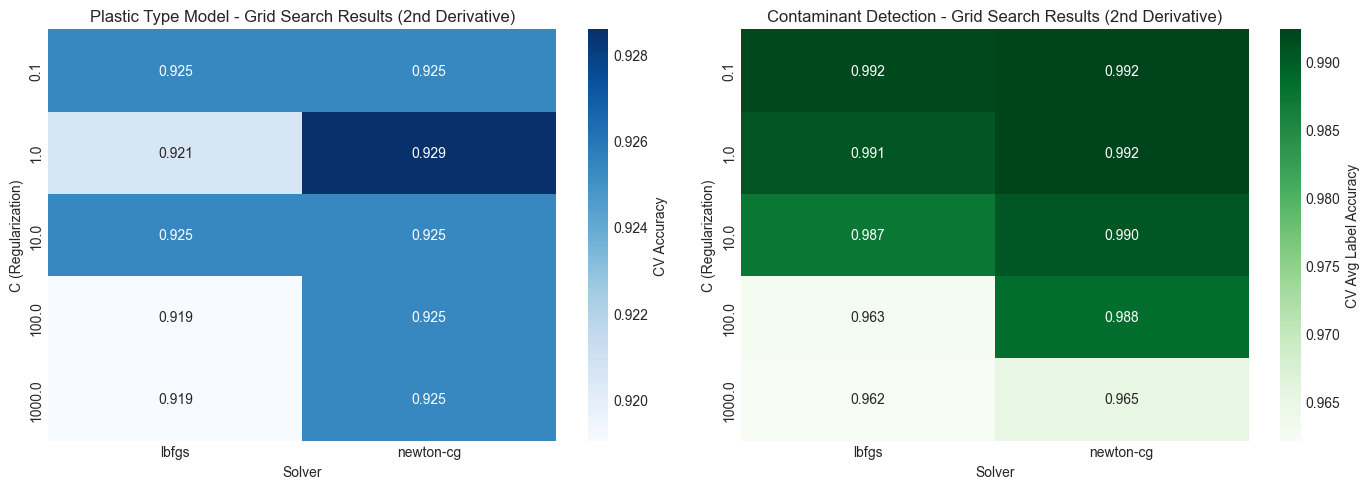


GRID SEARCH SUMMARY (Second Derivative)

Plastic Type Classification:
  Best params: C=1.0, solver=newton-cg
  Default accuracy: 0.9114 → Tuned accuracy: 0.9114

Contaminant Detection:
  Best params: C=0.1, solver=newton-cg
  Default Hamming Loss: 0.0063 → Tuned Hamming Loss: 0.0063


In [25]:
# ============================================================================
# Visualize Grid Search Results
# ============================================================================


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Plastic Type Grid Search Results
cv_results_plastic = pd.DataFrame(grid_search_plastic.cv_results_)
pivot_plastic = cv_results_plastic.pivot_table(
    values='mean_test_score', 
    index='param_C', 
    columns='param_solver'
)
sns.heatmap(pivot_plastic, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'CV Accuracy'})
axes[0].set_title('Plastic Type Model - Grid Search Results (2nd Derivative)', fontsize=12)
axes[0].set_xlabel('Solver')
axes[0].set_ylabel('C (Regularization)')



# Plot 2: Contaminant Detection Grid Search Results
cv_results_contaminant = pd.DataFrame(grid_search_contaminant.cv_results_)
pivot_contaminant = cv_results_contaminant.pivot_table(
    values='mean_test_score', 
    index='param_estimator__C', 
    columns='param_estimator__solver'
)
sns.heatmap(pivot_contaminant, annot=True, fmt='.3f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'CV Avg Label Accuracy'})
axes[1].set_title('Contaminant Detection - Grid Search Results (2nd Derivative)', fontsize=12)
axes[1].set_xlabel('Solver')
axes[1].set_ylabel('C (Regularization)')



plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_grid_search_results.png', dpi=150)
plt.show()


# Summary
print("\n" + "=" * 60)
print("GRID SEARCH SUMMARY (Second Derivative)")
print("=" * 60)
print(f"\nPlastic Type Classification:")
print(f"  Best params: C={grid_search_plastic.best_params_['C']}, solver={grid_search_plastic.best_params_['solver']}")
print(f"  Default accuracy: {accuracy_plastic:.4f} → Tuned accuracy: {accuracy_plastic_tuned:.4f}")

print(f"\nContaminant Detection:")
print(f"  Best params: C={grid_search_contaminant.best_params_['estimator__C']}, solver={grid_search_contaminant.best_params_['estimator__solver']}")
print(f"  Default Hamming Loss: {h_loss:.4f} → Tuned Hamming Loss: {h_loss_tuned:.4f}")




## 5. Combined Multi-Output Model

In [26]:
# Create combined labels (plastic type + contaminants)
# Plastic type as integer class (0-3) + contaminant binary labels
y_combined_train = np.column_stack([y_plastic_train.reshape(-1, 1), y_contaminant_train])
y_combined_test = np.column_stack([y_plastic_test.reshape(-1, 1), y_contaminant_test])

print(f"Combined labels shape (train): {y_combined_train.shape}")
print(f"Combined labels shape (test): {y_combined_test.shape}")
print(f"\nOutput dimensions:")
print(f"  Column 0: Plastic type (0={PLASTIC_TYPES[0]}, 1={PLASTIC_TYPES[1]}, 2={PLASTIC_TYPES[2]}, 3={PLASTIC_TYPES[3]})")
for i, cont in enumerate(CONTAMINANTS):
    print(f"  Column {i+1}: {cont} (0=absent, 1=present)")

Combined labels shape (train): (630, 7)
Combined labels shape (test): (158, 7)

Output dimensions:
  Column 0: Plastic type (0=PP, 1=LDPE, 2=LLDPE, 3=HDPE)
  Column 1: BSA (0=absent, 1=present)
  Column 2: Oil (0=absent, 1=present)
  Column 3: Starch (0=absent, 1=present)
  Column 4: CMC (0=absent, 1=present)
  Column 5: Guar (0=absent, 1=present)
  Column 6: Casein (0=absent, 1=present)


In [27]:
# Train combined multi-output model
base_lr_combined = LogisticRegression(
    solver='newton-cg',
    max_iter=5000,
    random_state=RANDOM_STATE,
    C=10.0  # Regularization strength
)

lr_combined = MultiOutputClassifier(base_lr_combined, n_jobs=-1)

print("Training Combined Multi-Output Logistic Regression Model...")
lr_combined.fit(X_train_scaled, y_combined_train)
print("Training complete!")

# Predictions
y_combined_pred = lr_combined.predict(X_test_scaled)

Training Combined Multi-Output Logistic Regression Model...
Training complete!


In [28]:
# Evaluate combined model
print("=" * 60)
print("COMBINED MODEL RESULTS")
print("=" * 60)

# Plastic type (first column)
plastic_acc_combined = accuracy_score(y_combined_test[:, 0], y_combined_pred[:, 0])
print(f"\nPlastic Type Accuracy: {plastic_acc_combined:.4f}")

# Contaminants (remaining columns)
contaminant_h_loss = hamming_loss(y_combined_test[:, 1:], y_combined_pred[:, 1:])
print(f"Contaminant Hamming Loss: {contaminant_h_loss:.4f}")

# Overall exact match ratio - computed manually since accuracy_score doesn't support multiclass-multioutput
# Check if ALL outputs match for each sample
overall_exact_match = np.all(y_combined_test == y_combined_pred, axis=1).mean()
print(f"Overall Exact Match Ratio: {overall_exact_match:.4f}")

COMBINED MODEL RESULTS

Plastic Type Accuracy: 0.9114
Contaminant Hamming Loss: 0.0063
Overall Exact Match Ratio: 0.8987


COMBINED MODEL - ERROR ANALYSIS FOR CONTAMINANT DETECTION


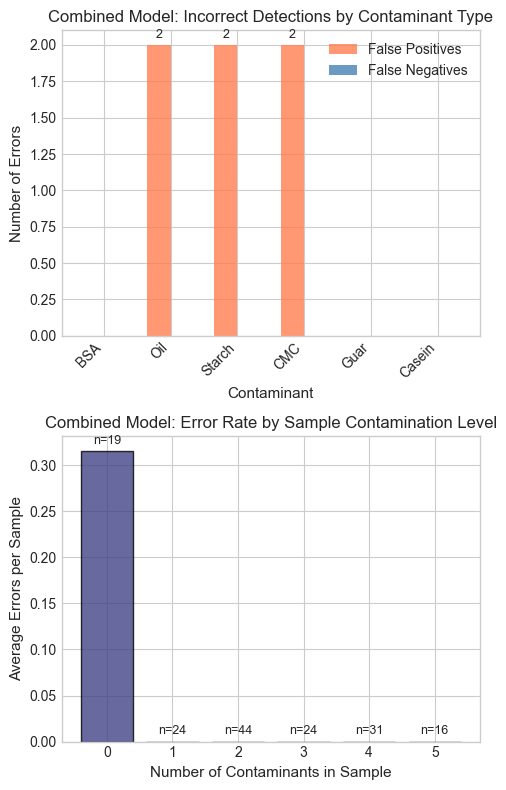


------------------------------------------------------------
ERROR SUMMARY BY CONTAMINANT (Combined Model)
------------------------------------------------------------
Contaminant     FP     FN    Total    FP Rate    FN Rate
------------------------------------------------------------
BSA             0      0        0       0.0%       0.0%
Oil             2      0        2       2.7%       0.0%
Starch          2      0        2       2.3%       0.0%
CMC             2      0        2       2.0%       0.0%
Guar            0      0        0       0.0%       0.0%
Casein          0      0        0       0.0%       0.0%
------------------------------------------------------------
TOTAL           6      0        6

Plastic Type Errors:           14
Total Contaminant Errors:      6

Samples with contaminant errors:    2/158 (1.3%)
Samples with plastic type error:    14/158 (8.9%)
Samples with BOTH types of errors:  0/158 (0.0%)


In [29]:
# Error Analysis for Combined Multi-Output Model
# Analyze incorrect contaminant detections from the combined model

print("=" * 60)
print("COMBINED MODEL - ERROR ANALYSIS FOR CONTAMINANT DETECTION")
print("=" * 60)

# Extract contaminant predictions from combined model (columns 1:)
y_combined_contam_true = y_combined_test[:, 1:]
y_combined_contam_pred = y_combined_pred[:, 1:]

# Calculate false positives and false negatives for each contaminant
fp_combined = np.zeros(len(CONTAMINANTS), dtype=int)
fn_combined = np.zeros(len(CONTAMINANTS), dtype=int)

for i, cont in enumerate(CONTAMINANTS):
    y_true_col = y_combined_contam_true[:, i]
    y_pred_col = y_combined_contam_pred[:, i]
    
    # False positives: predicted 1, actual 0
    fp_combined[i] = np.sum((y_pred_col == 1) & (y_true_col == 0))
    # False negatives: predicted 0, actual 1
    fn_combined[i] = np.sum((y_pred_col == 0) & (y_true_col == 1))

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

# Plot 1: False positives vs False negatives by contaminant
ax1 = axes[0]
x_pos = np.arange(len(CONTAMINANTS))
width = 0.35

bars_fp = ax1.bar(x_pos - width/2, fp_combined, width, label='False Positives', color='coral', alpha=0.8)
bars_fn = ax1.bar(x_pos + width/2, fn_combined, width, label='False Negatives', color='steelblue', alpha=0.8)

ax1.set_xlabel('Contaminant', fontsize=11)
ax1.set_ylabel('Number of Errors', fontsize=11)
ax1.set_title('Combined Model: Incorrect Detections by Contaminant Type', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(CONTAMINANTS, rotation=45, ha='right')
ax1.legend()

# Add value labels on bars
for bar in bars_fp:
    height = bar.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars_fn:
    height = bar.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Plot 2: Errors by number of contaminants in sample
ax2 = axes[1]

# Count contaminants per sample (from ground truth)
n_contam_per_sample = y_combined_contam_true.sum(axis=1).astype(int)

# Count errors per sample
errors_combined = (y_combined_contam_true != y_combined_contam_pred).sum(axis=1)

# Group errors by number of contaminants
unique_n = np.unique(n_contam_per_sample)
error_by_n = []
sample_count_by_n = []
avg_error_by_n = []

for n in unique_n:
    mask = n_contam_per_sample == n
    total_err = errors_combined[mask].sum()
    n_samples = mask.sum()
    error_by_n.append(total_err)
    sample_count_by_n.append(n_samples)
    avg_error_by_n.append(total_err / n_samples if n_samples > 0 else 0)

# Bar chart with average errors per sample
colors_n = plt.cm.viridis(np.linspace(0.2, 0.8, len(unique_n)))
bars_n = ax2.bar(unique_n, avg_error_by_n, color=colors_n, alpha=0.8, edgecolor='black')

ax2.set_xlabel('Number of Contaminants in Sample', fontsize=11)
ax2.set_ylabel('Average Errors per Sample', fontsize=11)
ax2.set_title('Combined Model: Error Rate by Sample Contamination Level', fontsize=12)
ax2.set_xticks(unique_n)

# Add sample count labels on bars
for bar, count, avg in zip(bars_n, sample_count_by_n, avg_error_by_n):
    height = bar.get_height()
    ax2.annotate(f'n={count}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_combined_model_error_analysis.png', dpi=150)
plt.show()

# Summary statistics
print("\n" + "-" * 60)
print("ERROR SUMMARY BY CONTAMINANT (Combined Model)")
print("-" * 60)
print(f"{'Contaminant':<10} {'FP':>6} {'FN':>6} {'Total':>8} {'FP Rate':>10} {'FN Rate':>10}")
print("-" * 60)

for i, cont in enumerate(CONTAMINANTS):
    n_absent = np.sum(y_combined_contam_true[:, i] == 0)
    n_present = np.sum(y_combined_contam_true[:, i] == 1)
    fp_rate = fp_combined[i] / n_absent * 100 if n_absent > 0 else 0
    fn_rate = fn_combined[i] / n_present * 100 if n_present > 0 else 0
    total = fp_combined[i] + fn_combined[i]
    print(f"{cont:<10} {fp_combined[i]:>6} {fn_combined[i]:>6} {total:>8} {fp_rate:>9.1f}% {fn_rate:>9.1f}%")

print("-" * 60)
print(f"{'TOTAL':<10} {fp_combined.sum():>6} {fn_combined.sum():>6} {fp_combined.sum() + fn_combined.sum():>8}")

# Compare with plastic type errors
plastic_errors = np.sum(y_combined_test[:, 0] != y_combined_pred[:, 0])
print(f"\n{'Plastic Type Errors:':<30} {plastic_errors}")
print(f"{'Total Contaminant Errors:':<30} {fp_combined.sum() + fn_combined.sum()}")

# Per-sample analysis
samples_with_errors = np.sum(errors_combined > 0)
samples_with_plastic_error = np.sum(y_combined_test[:, 0] != y_combined_pred[:, 0])
samples_with_both_errors = np.sum((errors_combined > 0) & (y_combined_test[:, 0] != y_combined_pred[:, 0]))

print(f"\n{'Samples with contaminant errors:':<35} {samples_with_errors}/{len(y_combined_test)} ({samples_with_errors/len(y_combined_test)*100:.1f}%)")
print(f"{'Samples with plastic type error:':<35} {samples_with_plastic_error}/{len(y_combined_test)} ({samples_with_plastic_error/len(y_combined_test)*100:.1f}%)")
print(f"{'Samples with BOTH types of errors:':<35} {samples_with_both_errors}/{len(y_combined_test)} ({samples_with_both_errors/len(y_combined_test)*100:.1f}%)")

## 6. Save Model and Results

In [30]:
import joblib
from datetime import datetime

# Create output directories if they don't exist
models_dir = Path('.').resolve()
reports_dir = project_root / 'reports' / 'text_reports'
figures_dir = project_root / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Save models (with second_derivative prefix to distinguish)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

joblib.dump(lr_plastic, models_dir / f'lr_second_derivative_plastic_model_{timestamp}.joblib')
joblib.dump(lr_contaminant, models_dir / f'lr_second_derivative_contaminant_model_{timestamp}.joblib')
joblib.dump(lr_combined, models_dir / f'lr_second_derivative_combined_model_{timestamp}.joblib')
joblib.dump(scaler, models_dir / f'scaler_second_derivative_{timestamp}.joblib')

# Also save the Savitzky-Golay parameters used
sg_params = {
    'window_length': window_length,
    'polyorder': polyorder,
    'deriv': 2
}
joblib.dump(sg_params, models_dir / f'savgol_params_{timestamp}.joblib')

print(f"Models saved to: {models_dir}")
print(f"Savitzky-Golay parameters saved: {sg_params}")

Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\logistic_regression
Savitzky-Golay parameters saved: {'window_length': 15, 'polyorder': 3, 'deriv': 2}


In [31]:
# Generate and save text report
report = f"""
================================================================================
LOGISTIC REGRESSION MODEL EVALUATION REPORT (SECOND DERIVATIVE)
================================================================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data: IR Spectral Data (Second Derivative via Savitzky-Golay)
Preprocessing: Savitzky-Golay filter (window={window_length}, polyorder={polyorder}, deriv=2)
Training samples: {X_train.shape[0]}
Test samples: {X_test.shape[0]}
Features: {X_train.shape[1]} (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: {PLASTIC_TYPES}
Test Accuracy: {accuracy_plastic:.4f}
Mean CV Accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})

{classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES)}

--------------------------------------------------------------------------------
2. CONTAMINANT DETECTION (Multi-label)
--------------------------------------------------------------------------------
Contaminants: {CONTAMINANTS}
Hamming Loss: {h_loss:.4f}
Exact Match Ratio: {exact_match:.4f}

Per-contaminant Performance:
"""

for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    report += f"  {contaminant}: Accuracy={acc:.4f}, F1-Score={f1:.4f}\n"

report += f"""
--------------------------------------------------------------------------------
3. COMBINED MODEL
--------------------------------------------------------------------------------
Plastic Type Accuracy: {plastic_acc_combined:.4f}
Contaminant Hamming Loss: {contaminant_h_loss:.4f}
Overall Exact Match Ratio: {overall_exact_match:.4f}

================================================================================
"""

# Save report
report_path = reports_dir / f'lr_second_derivative_evaluation_report_{timestamp}.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\nReport saved to: {report_path}")


LOGISTIC REGRESSION MODEL EVALUATION REPORT (SECOND DERIVATIVE)
Date: 2026-03-02 11:08:57
Data: IR Spectral Data (Second Derivative via Savitzky-Golay)
Preprocessing: Savitzky-Golay filter (window=15, polyorder=3, deriv=2)
Training samples: 630
Test samples: 158
Features: 7469 (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: ['PP', 'LDPE', 'LLDPE', 'HDPE']
Test Accuracy: 0.9114
Mean CV Accuracy: 0.9254 (+/- 0.0356)

              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       1.00      0.68      0.81        38
       LLDPE       0.82      0.95      0.88        38
        HDPE       0.89      1.00      0.94        48

    accuracy                           0.91       158
   macro avg       0.93      0.91      0.91       158
weighted av

## 7. Model Coefficients Analysis

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3843424662.py:18: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3843424662.py:19: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_coefficients_plastic.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


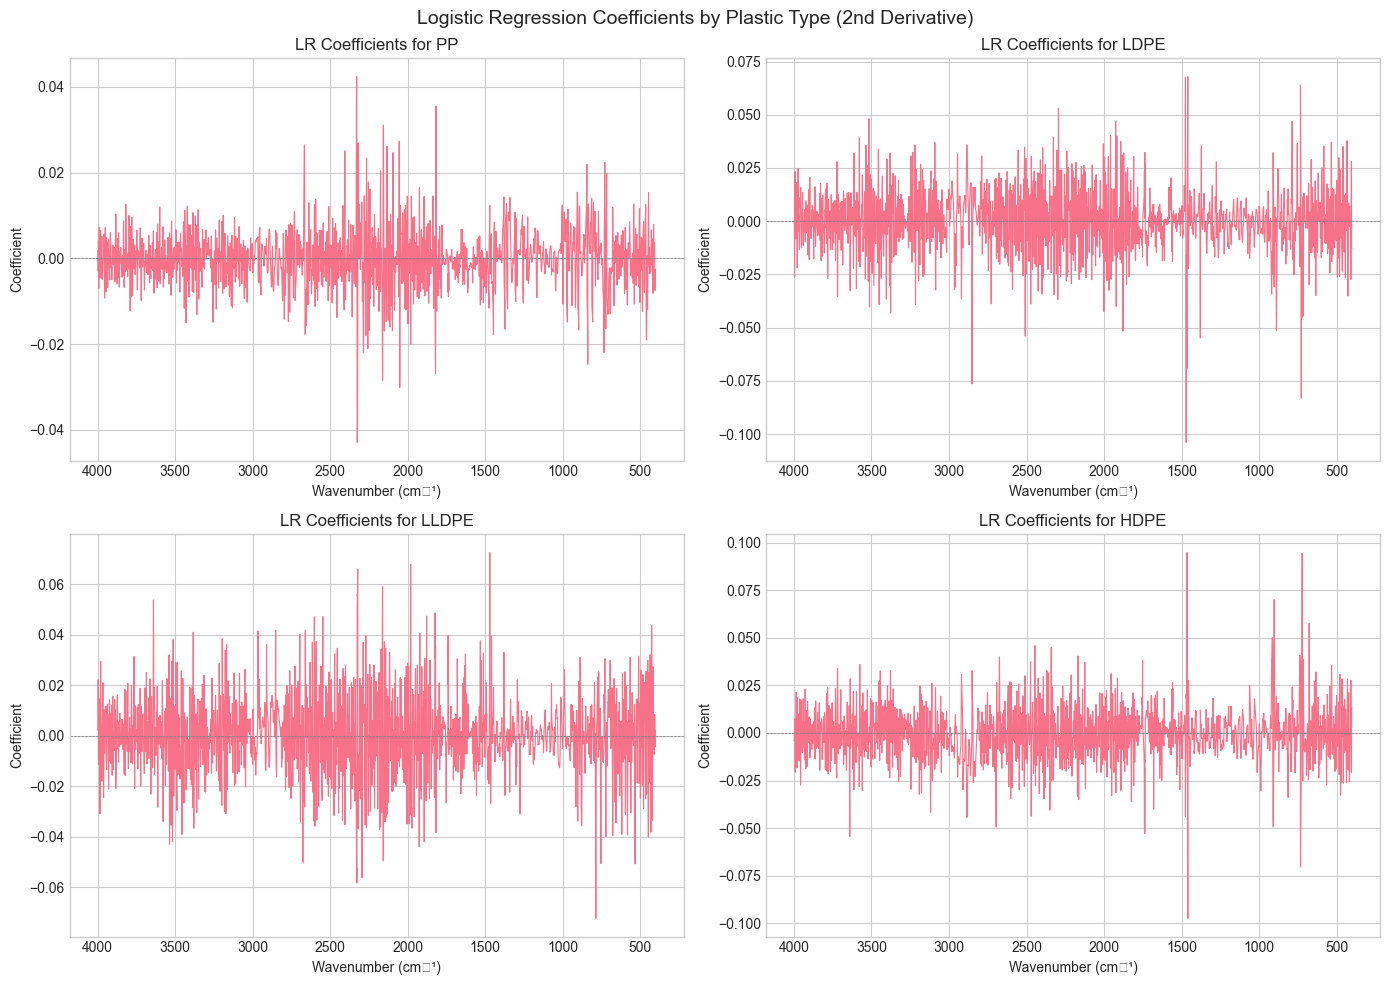


TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE

PP:
------------------------------------------------------------
 Rank Wavenumber (cm⁻¹) Coefficient Direction
    1            2325.3     -0.0429  Negative
    2            2324.8     -0.0424  Negative
    3            2329.1      0.0424  Positive
    4            2328.7      0.0422  Positive
    5            2324.3     -0.0414  Negative
    6            2329.6      0.0408  Positive
    7            2328.2      0.0404  Positive
    8            2325.8     -0.0401  Negative
    9            2323.8     -0.0398  Negative
   10            2323.4     -0.0388  Negative
   11            2327.7      0.0379  Positive
   12            2322.9     -0.0378  Negative
   13            2330.1      0.0376  Positive
   14            2322.4     -0.0364  Negative
   15            1816.6      0.0356  Positive
   16            1816.2      0.0354  Positive
   17            2327.2      0.0343  Positive
   18            1817.1      0.0336  Positive
   19       

In [32]:
# Visualize logistic regression coefficients for plastic type model
# This shows which wavenumbers are most important for classification

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ax, plastic) in enumerate(zip(axes, PLASTIC_TYPES)):
    coefficients = lr_plastic.coef_[i]
    
    ax.plot(wavenumbers, coefficients, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Coefficient', fontsize=10)
    ax.set_title(f'LR Coefficients for {plastic}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()  # IR spectra convention

plt.suptitle('Logistic Regression Coefficients by Plastic Type (2nd Derivative)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_coefficients_plastic.png', dpi=150)
plt.show()

# Create table of top 20 most important features for each plastic type
print("\n" + "=" * 80)
print("TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE")
print("=" * 80)

for i, plastic in enumerate(PLASTIC_TYPES):
    coefficients = lr_plastic.coef_[i]
    
    # Get indices sorted by absolute coefficient value (descending)
    top_indices = np.argsort(np.abs(coefficients))[::-1][:20]
    
    # Create DataFrame for display
    top_features_df = pd.DataFrame({
        'Rank': range(1, 21),
        'Wavenumber (cm⁻¹)': [f"{wavenumbers[idx]:.1f}" for idx in top_indices],
        'Coefficient': [f"{coefficients[idx]:.4f}" for idx in top_indices],
        'Direction': ['Positive' if coefficients[idx] > 0 else 'Negative' for idx in top_indices]
    })
    
    print(f"\n{plastic}:")
    print("-" * 60)
    print(top_features_df.to_string(index=False))

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3358609972.py:19: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3358609972.py:20: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_coefficients_contaminant.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


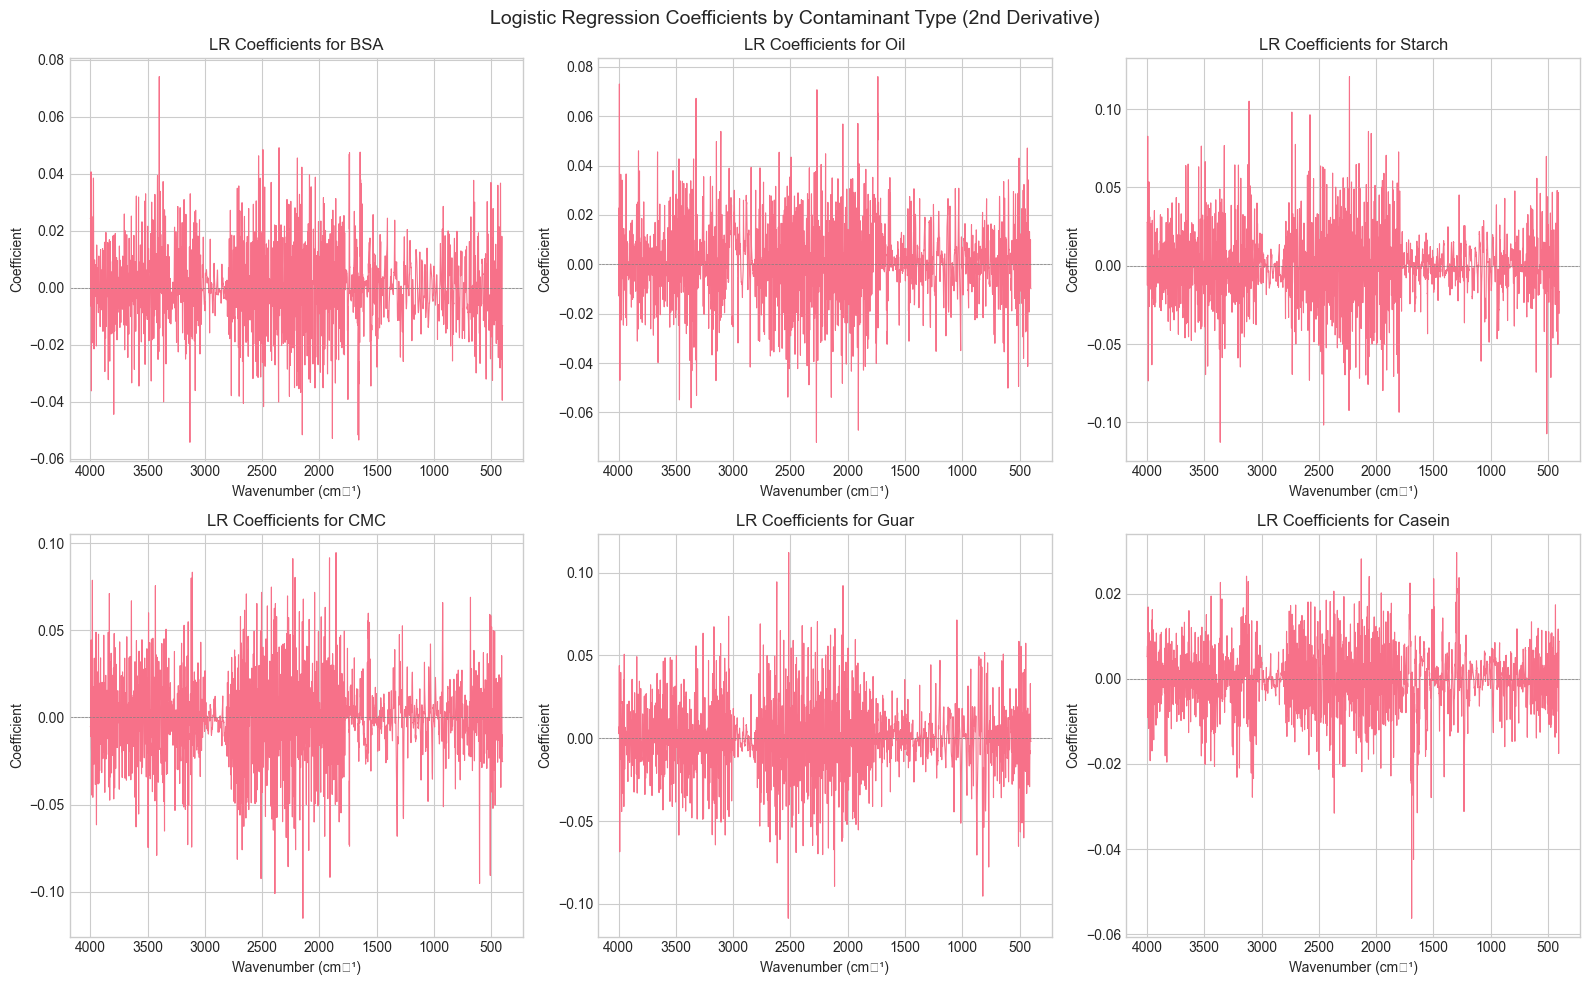

In [33]:
# Visualize logistic regression coefficients for contaminant detection model
# This shows which wavenumbers are most important for detecting each contaminant

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    # Each estimator in MultiOutputClassifier has coef_ for binary classification
    coefficients = lr_contaminant.estimators_[i].coef_[0]
    
    ax.plot(wavenumbers, coefficients, linewidth=0.8)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Coefficient', fontsize=10)
    ax.set_title(f'LR Coefficients for {contaminant}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()  # IR spectra convention

plt.suptitle('Logistic Regression Coefficients by Contaminant Type (2nd Derivative)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_coefficients_contaminant.png', dpi=150)
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\2623865732.py:35: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\2623865732.py:36: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_standardized_coefficients_contaminant.png', dpi=150)


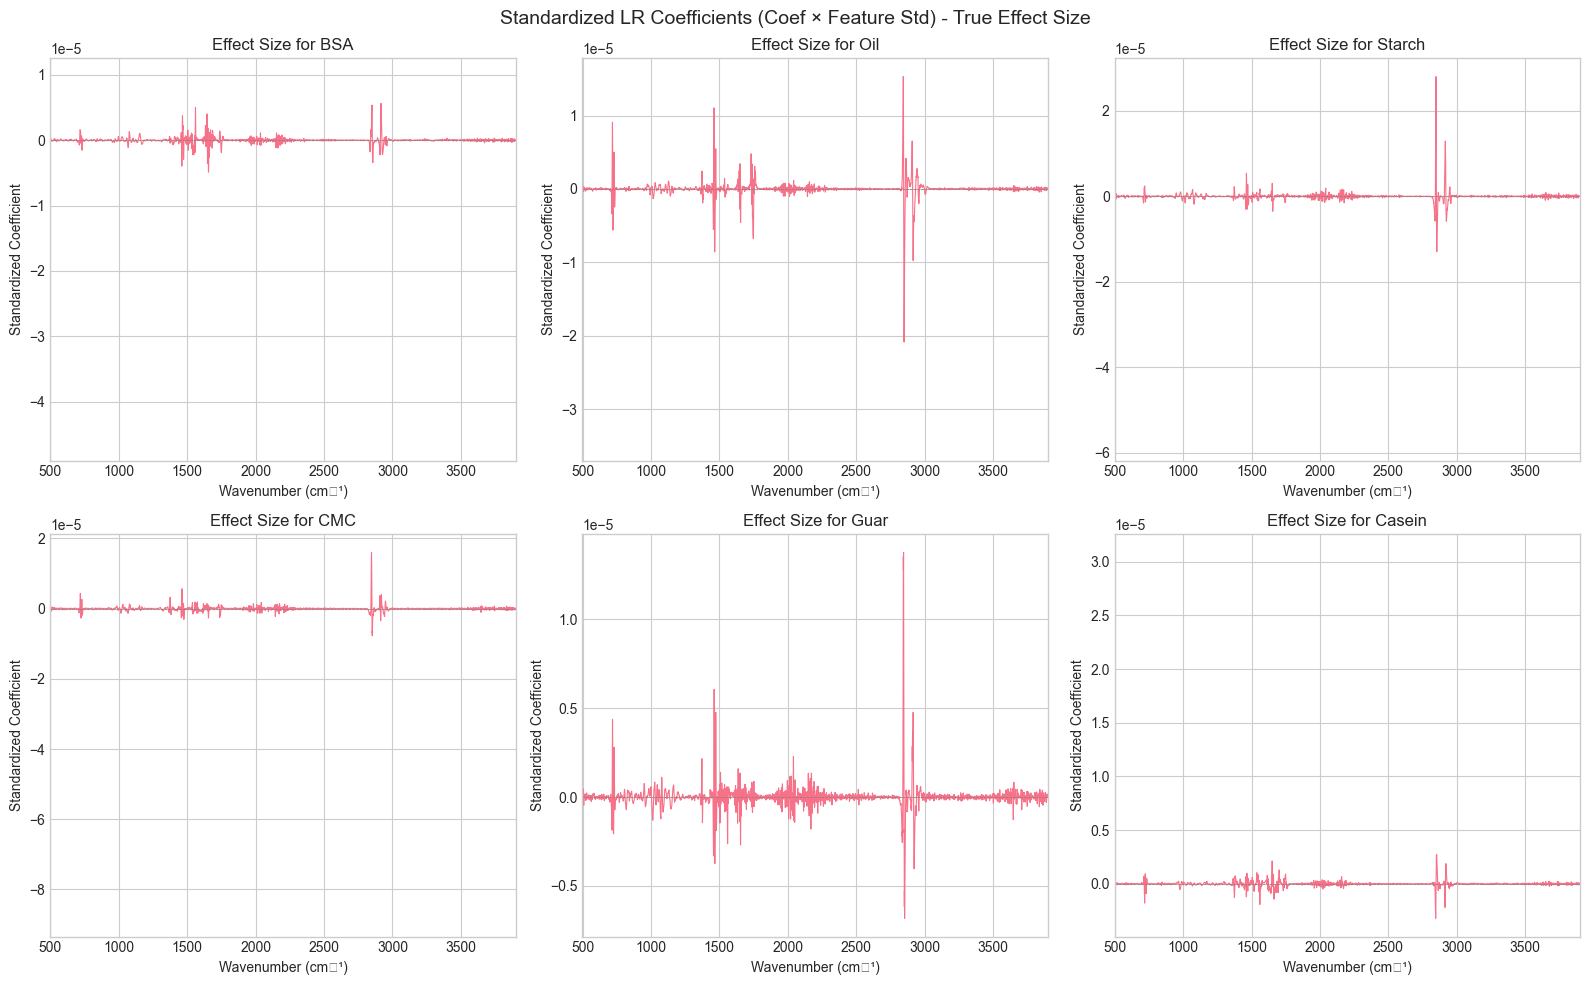

Standardized coefficients show the actual effect size:
  - Accounts for feature variance at each wavenumber
  - Valley regions with low variance will have reduced importance
  - Peak regions with high variance will show their true contribution


In [34]:
# ============================================================================
# IMPROVED FEATURE IMPORTANCE VISUALIZATION
# ============================================================================
# Raw coefficients don't account for feature variance - a large coefficient
# on a low-variance feature (valley) has less actual impact than a smaller
# coefficient on a high-variance feature (peak).

# Method 1: Standardized Coefficients (coefficient × feature std)
# This gives the change in log-odds per 1 standard deviation change in the feature
# More meaningful than raw coefficients for second derivative data

# Get the original feature standard deviations (before scaling)
feature_stds = np.std(X_train, axis=0)  # Standard deviation at each wavenumber

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    # Raw coefficients
    coefficients = lr_contaminant.estimators_[i].coef_[0]
    
    # Standardized coefficients = coef × std(feature)
    # This represents the actual contribution to the prediction
    standardized_coef = coefficients * feature_stds
    
    ax.plot(wavenumbers, standardized_coef, linewidth=0.8)
    ax.set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Standardized Coefficient', fontsize=10)
    ax.set_title(f'Effect Size for {contaminant}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.invert_xaxis()

plt.suptitle('Standardized LR Coefficients (Coef × Feature Std) - True Effect Size', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_standardized_coefficients_contaminant.png', dpi=150)
plt.show()

print("Standardized coefficients show the actual effect size:")
print("  - Accounts for feature variance at each wavenumber")
print("  - Valley regions with low variance will have reduced importance")
print("  - Peak regions with high variance will show their true contribution")

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\72922283.py:25: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\72922283.py:26: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_standardized_coefficients_contaminant.png', dpi=150)


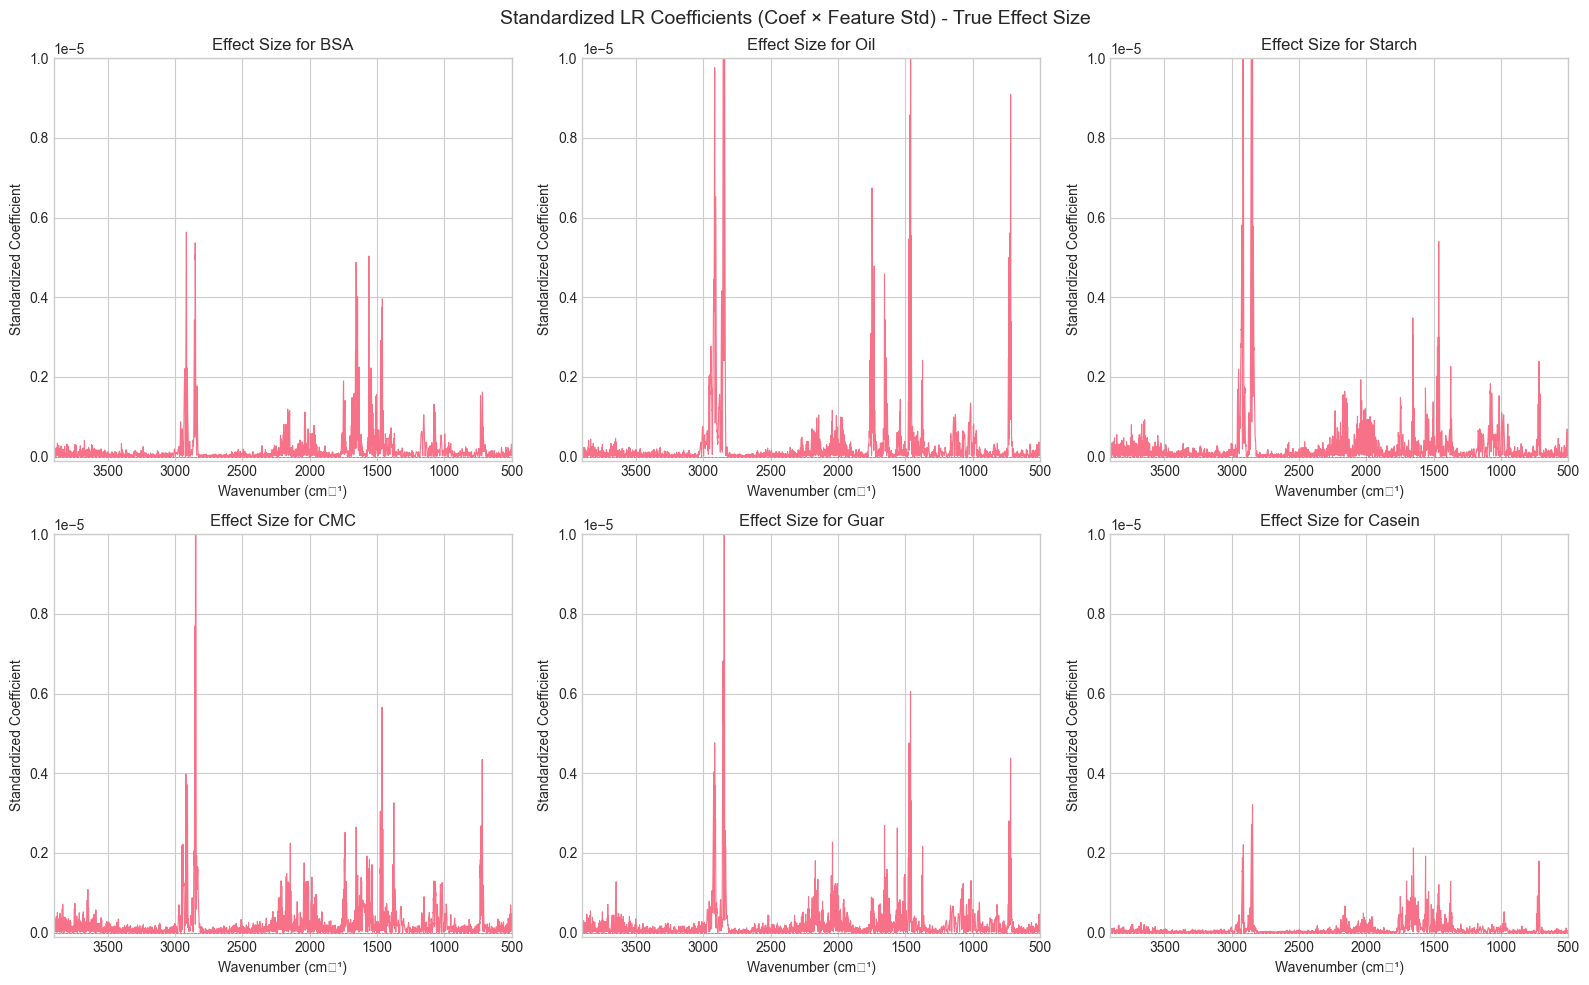

Standardized coefficients show the actual effect size:
  - Accounts for feature variance at each wavenumber
  - Valley regions with low variance will have reduced importance
  - Peak regions with high variance will show their true contribution


In [35]:
# Get the original feature standard deviations (before scaling)
feature_stds = np.std(X_train, axis=0)  # Standard deviation at each wavenumber

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    # Raw coefficients
    coefficients = lr_contaminant.estimators_[i].coef_[0]
    
    # Standardized coefficients = coef × std(feature)
    # This represents the actual contribution to the prediction
    standardized_coef = coefficients * feature_stds
    
    ax.plot(wavenumbers, np.abs(standardized_coef), linewidth=0.8)
    ax.set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)
    ax.set_ylim(-1*10**-7,1*10**-5)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Standardized Coefficient', fontsize=10)
    ax.set_title(f'Effect Size for {contaminant}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)


plt.suptitle('Standardized LR Coefficients (Coef × Feature Std) - True Effect Size', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_standardized_coefficients_contaminant.png', dpi=150)
plt.show()

print("Standardized coefficients show the actual effect size:")
print("  - Accounts for feature variance at each wavenumber")
print("  - Valley regions with low variance will have reduced importance")
print("  - Peak regions with high variance will show their true contribution")

Computing GROUPED Permutation Importance for Contaminant Detection...
(Grouping adjacent wavenumbers to handle correlation)

  Total features: 7469
  Group size: 75 wavenumbers
  Number of groups: 99

  Processing BSA... done
  Processing Oil... done
  Processing Starch... done
  Processing CMC... done
  Processing Guar... done
  Processing Casein... done

Grouped permutation importance computed!


C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\4266496153.py:114: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\4266496153.py:115: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_grouped_permutation_importance.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


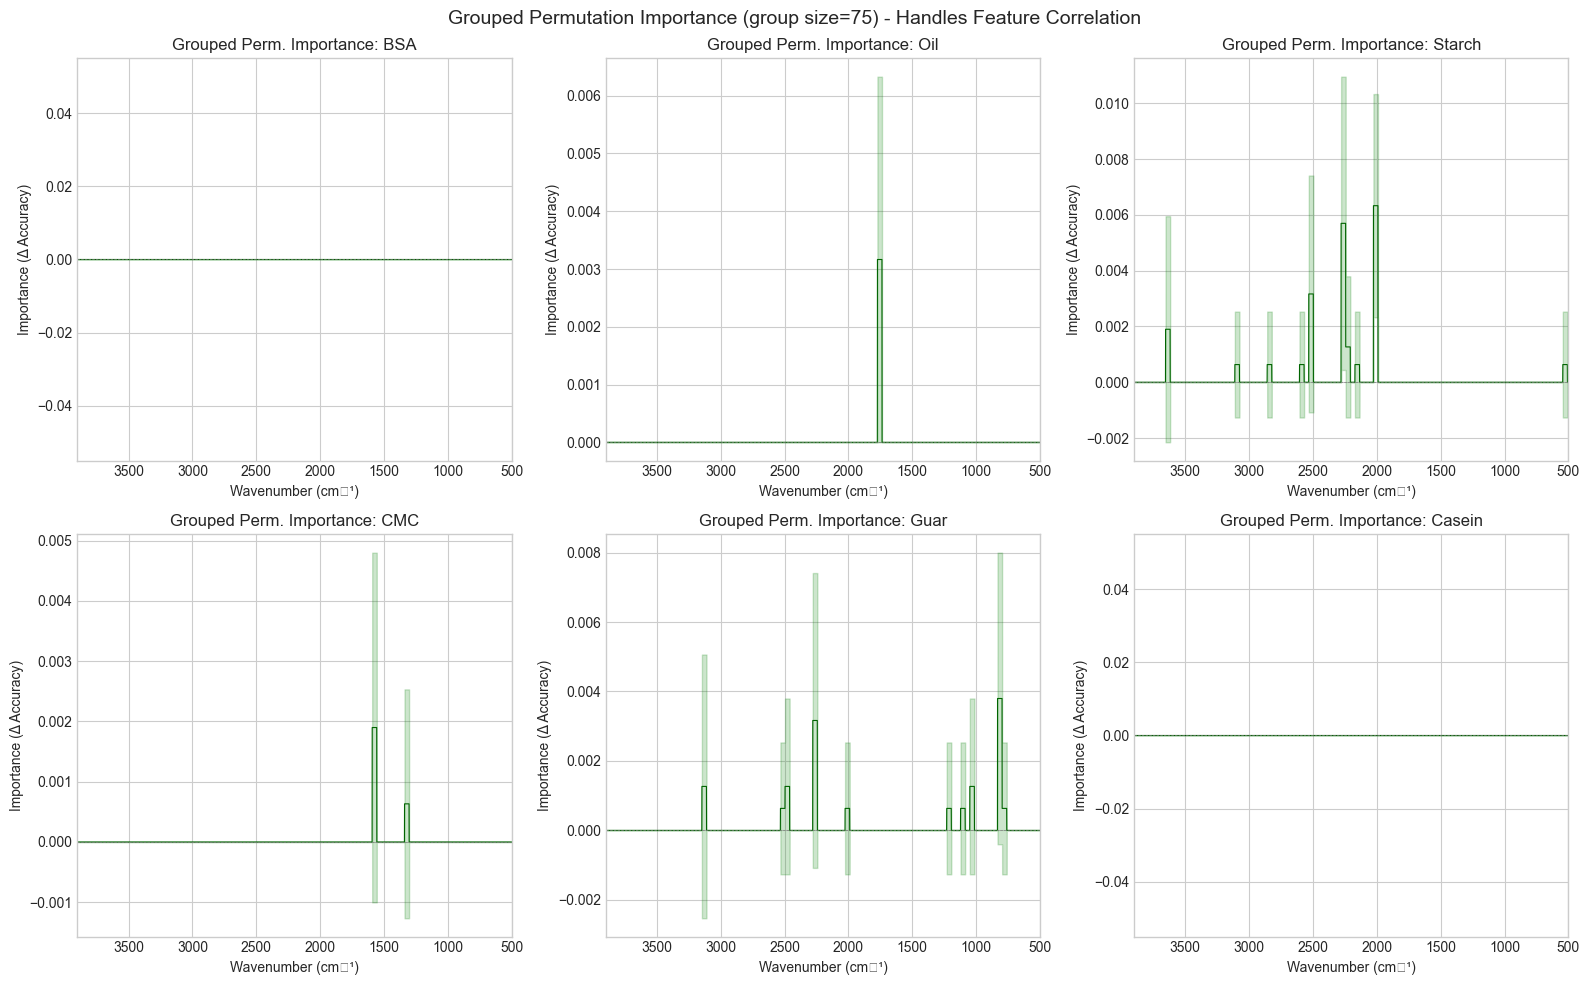


Grouped permutation importance interpretation:
  - Shuffles groups of adjacent wavenumbers together
  - Overcomes the issue of highly correlated spectral features
  - Positive values: Feature region contributes to correct predictions
  - Higher values: More important spectral region


In [36]:
# Method 2: Grouped Permutation Importance
# Standard permutation importance fails for spectral data because adjacent 
# wavenumbers are highly correlated - shuffling one feature is compensated by neighbors.
# Solution: Shuffle GROUPS of adjacent wavenumbers together.

print("Computing GROUPED Permutation Importance for Contaminant Detection...")
print("(Grouping adjacent wavenumbers to handle correlation)\n")

# Define group size (number of adjacent wavenumbers to shuffle together)
group_size = 75  # Adjust based on spectral resolution
n_features = X_test_scaled.shape[1]
n_groups = n_features // group_size

print(f"  Total features: {n_features}")
print(f"  Group size: {group_size} wavenumbers")
print(f"  Number of groups: {n_groups}\n")

def grouped_permutation_importance(estimator, X, y, group_size=20, n_repeats=10, random_state=42):
    """
    Compute permutation importance by shuffling groups of adjacent features.
    Returns importance per feature (averaged within groups).
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    n_groups = n_features // group_size
    
    # Baseline score
    baseline_score = estimator.score(X, y)
    
    # Store importance for each group
    group_importances = np.zeros((n_groups, n_repeats))
    
    for g in range(n_groups):
        start_idx = g * group_size
        end_idx = start_idx + group_size
        
        for r in range(n_repeats):
            # Copy data
            X_permuted = X.copy()
            
            # Shuffle the entire group of features together
            perm_idx = np.random.permutation(n_samples)
            X_permuted[:, start_idx:end_idx] = X_permuted[perm_idx, start_idx:end_idx]
            
            # Score with permuted features
            permuted_score = estimator.score(X_permuted, y)
            group_importances[g, r] = baseline_score - permuted_score
    
    # Average across repeats
    group_importance_mean = group_importances.mean(axis=1)
    group_importance_std = group_importances.std(axis=1)
    
    # Expand back to per-feature importance (assign group importance to all features in group)
    feature_importance_mean = np.zeros(n_features)
    feature_importance_std = np.zeros(n_features)
    
    for g in range(n_groups):
        start_idx = g * group_size
        end_idx = start_idx + group_size
        feature_importance_mean[start_idx:end_idx] = group_importance_mean[g]
        feature_importance_std[start_idx:end_idx] = group_importance_std[g]
    
    return {
        'importances_mean': feature_importance_mean,
        'importances_std': feature_importance_std,
        'group_importances_mean': group_importance_mean,
        'group_importances_std': group_importance_std
    }

# Compute grouped permutation importance for each contaminant model
perm_importance_results = []

for i, contaminant in enumerate(CONTAMINANTS):
    print(f"  Processing {contaminant}...", end=" ")
    
    # Get the individual estimator for this contaminant
    estimator = lr_contaminant.estimators_[i]
    
    # Compute grouped permutation importance on test set
    perm_result = grouped_permutation_importance(
        estimator, 
        X_test_scaled, 
        y_contaminant_test[:, i],
        group_size=group_size,
        n_repeats=10,
        random_state=RANDOM_STATE
    )
    perm_importance_results.append(perm_result)
    print("done")

print("\nGrouped permutation importance computed!")

# Visualize permutation importance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    importance_mean = perm_importance_results[i]['importances_mean']
    importance_std = perm_importance_results[i]['importances_std']
    
    ax.plot(wavenumbers, importance_mean, linewidth=0.8, color='darkgreen')
    ax.set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)
    ax.fill_between(wavenumbers, 
                    importance_mean - importance_std,
                    importance_mean + importance_std,
                    alpha=0.2, color='green')
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Importance (Δ Accuracy)', fontsize=10)
    ax.set_title(f'Grouped Perm. Importance: {contaminant}', fontsize=12)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)


plt.suptitle(f'Grouped Permutation Importance (group size={group_size}) - Handles Feature Correlation', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_grouped_permutation_importance.png', dpi=150)
plt.show()

print("\nGrouped permutation importance interpretation:")
print("  - Shuffles groups of adjacent wavenumbers together")
print("  - Overcomes the issue of highly correlated spectral features")
print("  - Positive values: Feature region contributes to correct predictions")
print("  - Higher values: More important spectral region")

TOP 10 MOST SIGNIFICANT SPECTRAL REGIONS BY CONTAMINANT
(Based on Grouped Permutation Importance)

BSA:
----------------------------------------------------------------------
Rank   Wavenumber Range (cm⁻¹)        Importance (Δ Acc)  
----------------------------------------------------------------------
1      3979.0 - 3943.3                0.000000            
2      1303.2 - 1267.5                0.000000            
3      1375.5 - 1339.8                0.000000            
4      1411.7 - 1376.0                0.000000            
5      1447.8 - 1412.1                0.000000            
6      1484.0 - 1448.3                0.000000            
7      1520.1 - 1484.5                0.000000            
8      1556.3 - 1520.6                0.000000            
9      1592.5 - 1556.8                0.000000            
10     1628.6 - 1592.9                0.000000            

Oil:
----------------------------------------------------------------------
Rank   Wavenumber Range (cm⁻

C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\2021059415.py:73: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\2021059415.py:74: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_importance_comparison.png', dpi=150)


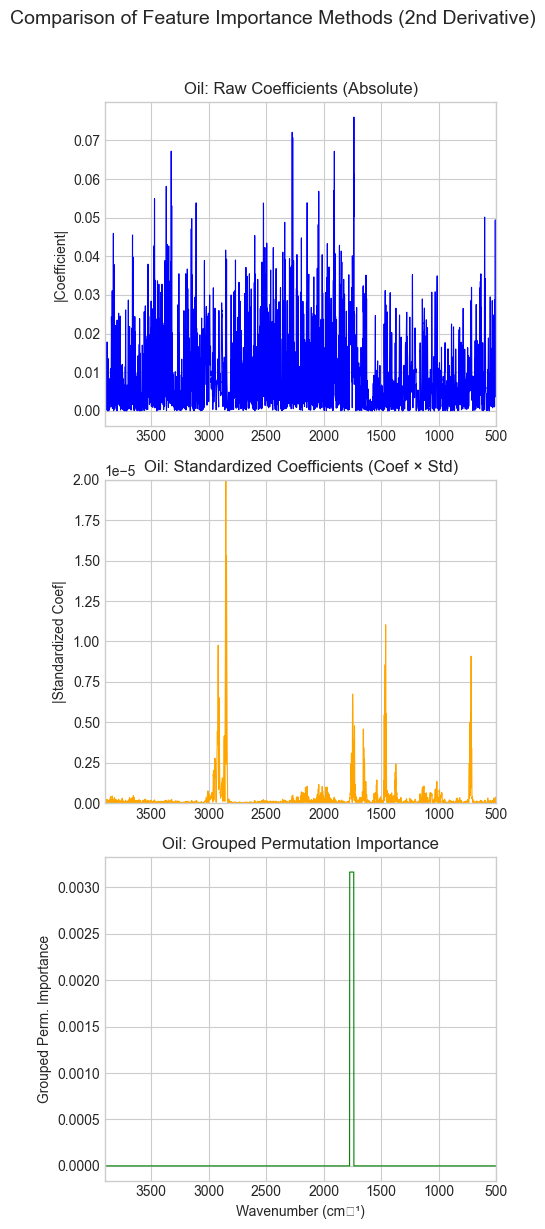

In [37]:
# Method 3: Top Important Wavenumber Regions Summary
# Identify and display the most significant spectral regions for each contaminant

print("=" * 80)
print("TOP 10 MOST SIGNIFICANT SPECTRAL REGIONS BY CONTAMINANT")
print("(Based on Grouped Permutation Importance)")
print("=" * 80)

# Get group center wavenumbers
group_centers = []
for g in range(n_groups):
    start_idx = g * group_size
    end_idx = start_idx + group_size
    center_wn = wavenumbers[start_idx:end_idx].mean()
    group_centers.append(center_wn)
group_centers = np.array(group_centers)

for i, contaminant in enumerate(CONTAMINANTS):
    group_importance = perm_importance_results[i]['group_importances_mean']
    
    # Get top 10 most important group indices
    top_group_indices = np.argsort(group_importance)[::-1][:10]
    
    print(f"\n{contaminant}:")
    print("-" * 70)
    print(f"{'Rank':<6} {'Wavenumber Range (cm⁻¹)':<30} {'Importance (Δ Acc)':<20}")
    print("-" * 70)
    
    for rank, g_idx in enumerate(top_group_indices, 1):
        start_idx = g_idx * group_size
        end_idx = start_idx + group_size
        wn_start = wavenumbers[start_idx]
        wn_end = wavenumbers[min(end_idx-1, len(wavenumbers)-1)]
        importance = group_importance[g_idx]
        print(f"{rank:<6} {wn_end:.1f} - {wn_start:.1f}{'':<15} {importance:<20.6f}")

# Create comparison plot: Raw Coefficients vs Standardized vs Grouped Permutation Importance
fig, axes = plt.subplots(3, 1, figsize=(5,12))

# Select one example contaminant for detailed comparison
example_contaminants = [1] 

for cont_idx in example_contaminants:
    contaminant = CONTAMINANTS[cont_idx]
    
    # Raw coefficients
    raw_coef = lr_contaminant.estimators_[cont_idx].coef_[0]
    axes[0].plot(wavenumbers, np.abs(raw_coef), linewidth=0.8, color='blue')
    axes[0].set_ylabel('|Coefficient|')
    axes[0].set_title(f'{contaminant}: Raw Coefficients (Absolute)')
    axes[0].set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)

    
    # Standardized coefficients
    std_coef = raw_coef * feature_stds
    axes[1].plot(wavenumbers, np.abs(std_coef), linewidth=0.8, color='orange')
    axes[1].set_ylabel('|Standardized Coef|')
    axes[1].set_title(f'{contaminant}: Standardized Coefficients (Coef × Std)')
    axes[1].set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)
    axes[1].set_ylim(0, 2*10**-5)

    
    # Grouped permutation importance
    perm_imp = perm_importance_results[cont_idx]['importances_mean']
    axes[2].plot(wavenumbers, perm_imp, linewidth=0.8, color='green')
    axes[2].set_xlabel('Wavenumber (cm⁻¹)')
    axes[2].set_ylabel('Grouped Perm. Importance')
    axes[2].set_title(f'{contaminant}: Grouped Permutation Importance')
    axes[2].set_xlim(wavenumbers.max()-100, wavenumbers.min()+100)


plt.suptitle('Comparison of Feature Importance Methods (2nd Derivative)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'lr_second_derivative_importance_comparison.png', dpi=150)
plt.show()






In [38]:
print("Logistic Regression model (Second Derivative) training and evaluation complete!")
print(f"\nPreprocessing: Savitzky-Golay second derivative")
print(f"  Window length: {window_length}, Polynomial order: {polyorder}")
print(f"\nSummary:")
print(f"  - Plastic Type Classification Accuracy: {accuracy_plastic:.2%}")
print(f"  - Contaminant Detection Hamming Loss: {h_loss:.4f}")
print(f"  - Models saved to: {models_dir}")
print(f"  - Reports saved to: {reports_dir}")
print(f"  - Figures saved to: {figures_dir}")

Logistic Regression model (Second Derivative) training and evaluation complete!

Preprocessing: Savitzky-Golay second derivative
  Window length: 15, Polynomial order: 3

Summary:
  - Plastic Type Classification Accuracy: 91.14%
  - Contaminant Detection Hamming Loss: 0.0063
  - Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\logistic_regression
  - Reports saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports
  - Figures saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\figures


ORIGINAL SPECTRUM vs STANDARDIZED COEFFICIENTS COMPARISON

BSA: Using sample 28 (1203-56-1 PP in 10% Oil + 16% BSA + 0.5% Guar-1.CSV)


C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\131429117.py:74: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\131429117.py:90: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / f'lr_spectrum_vs_coef_{cont_name}.png', dpi=150)


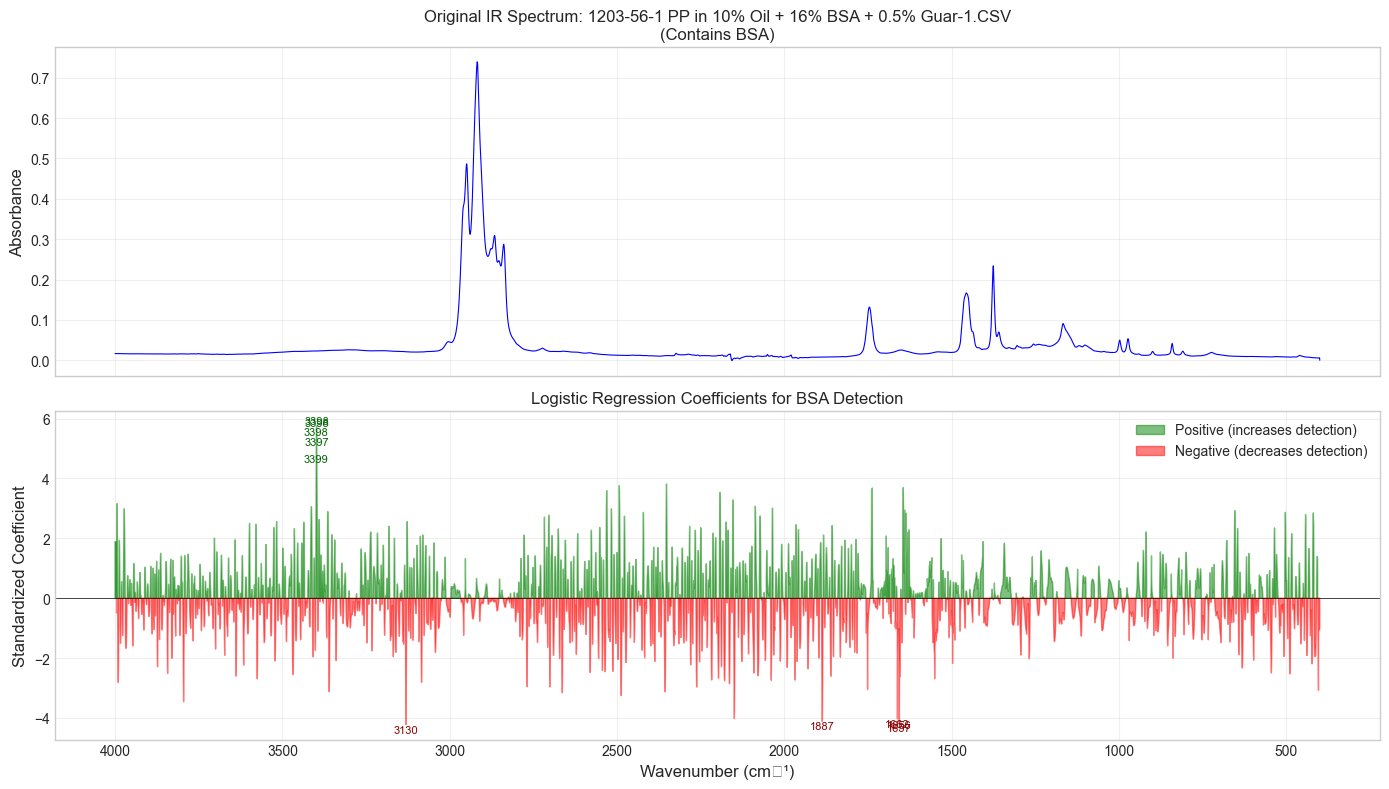


Oil: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


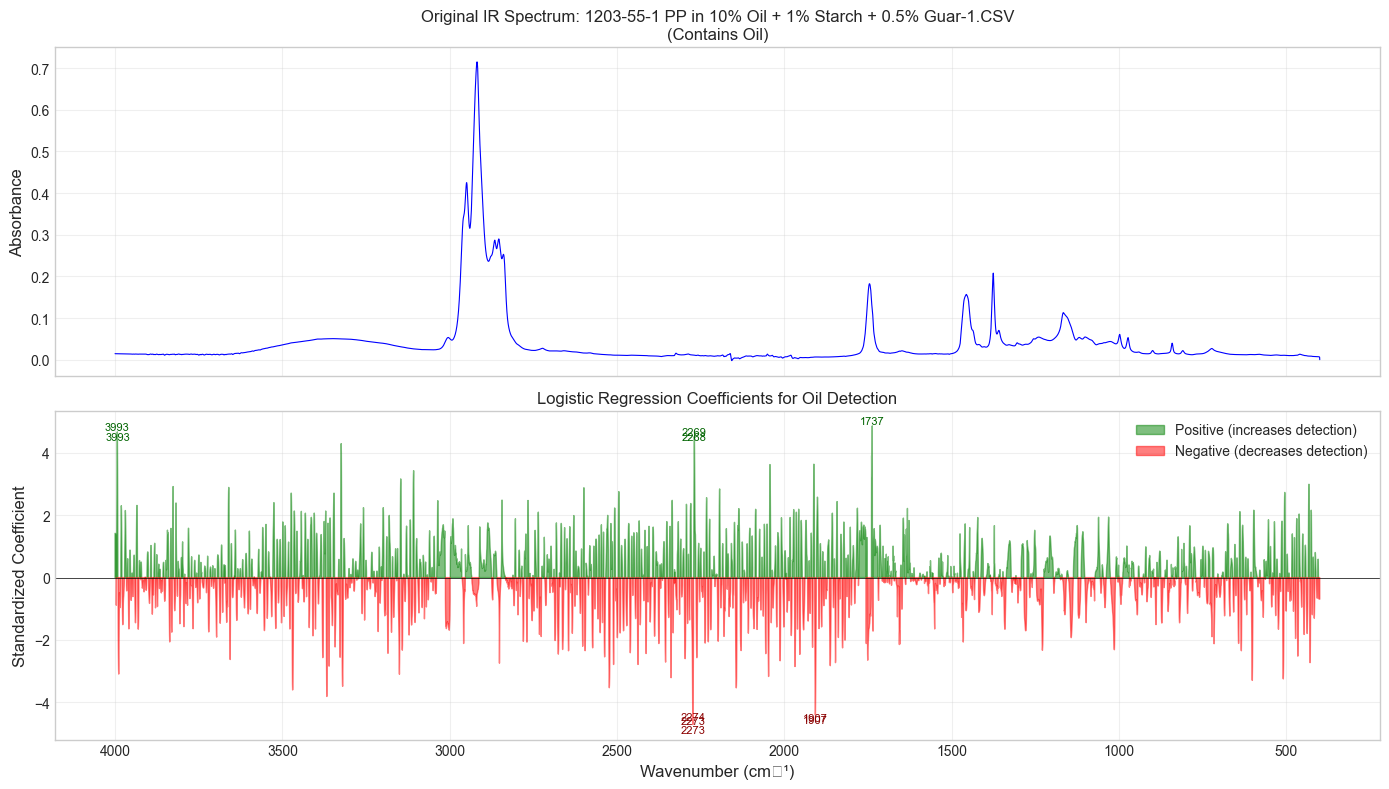


Starch: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


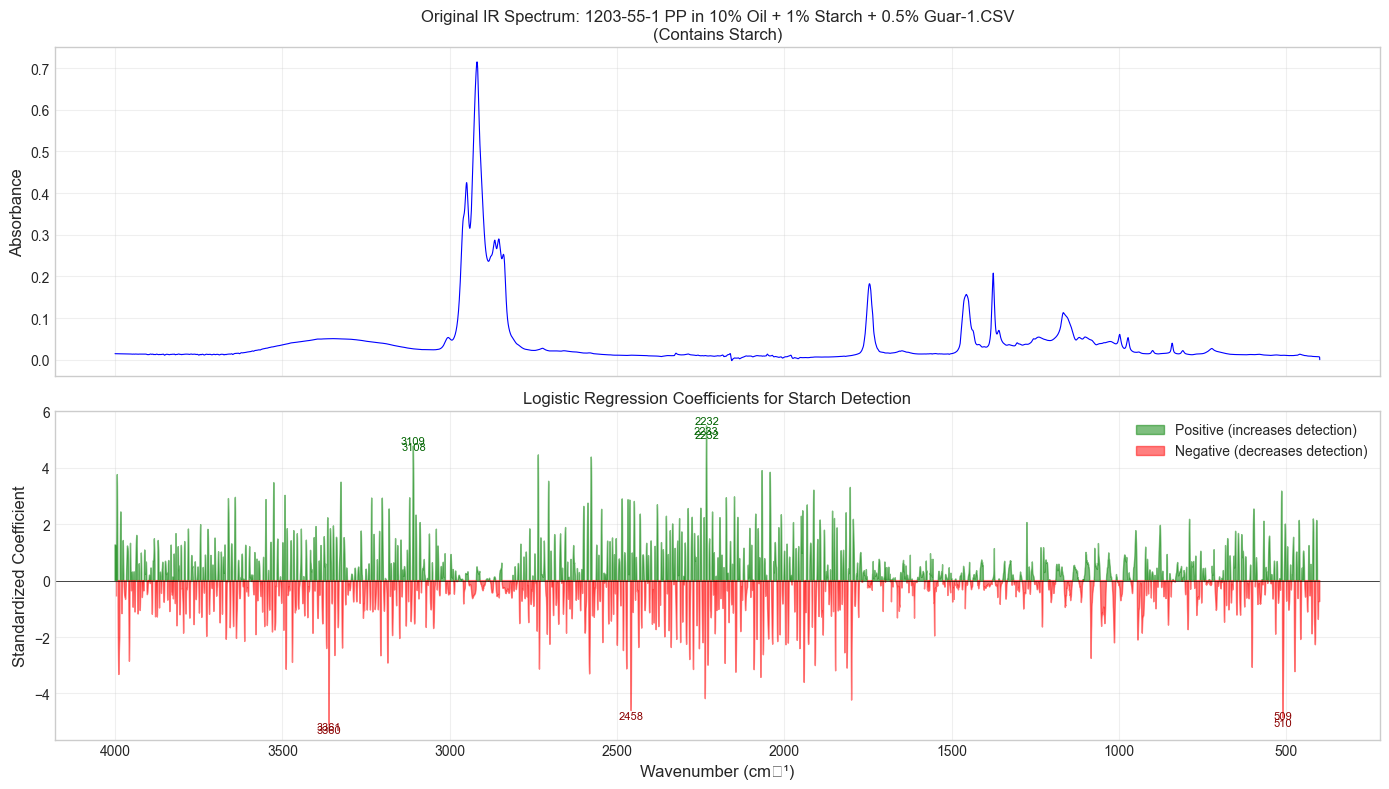


CMC: Using sample 56 (1203-58-1 PP in 0.5% Guar + 1% CMC-1.CSV)


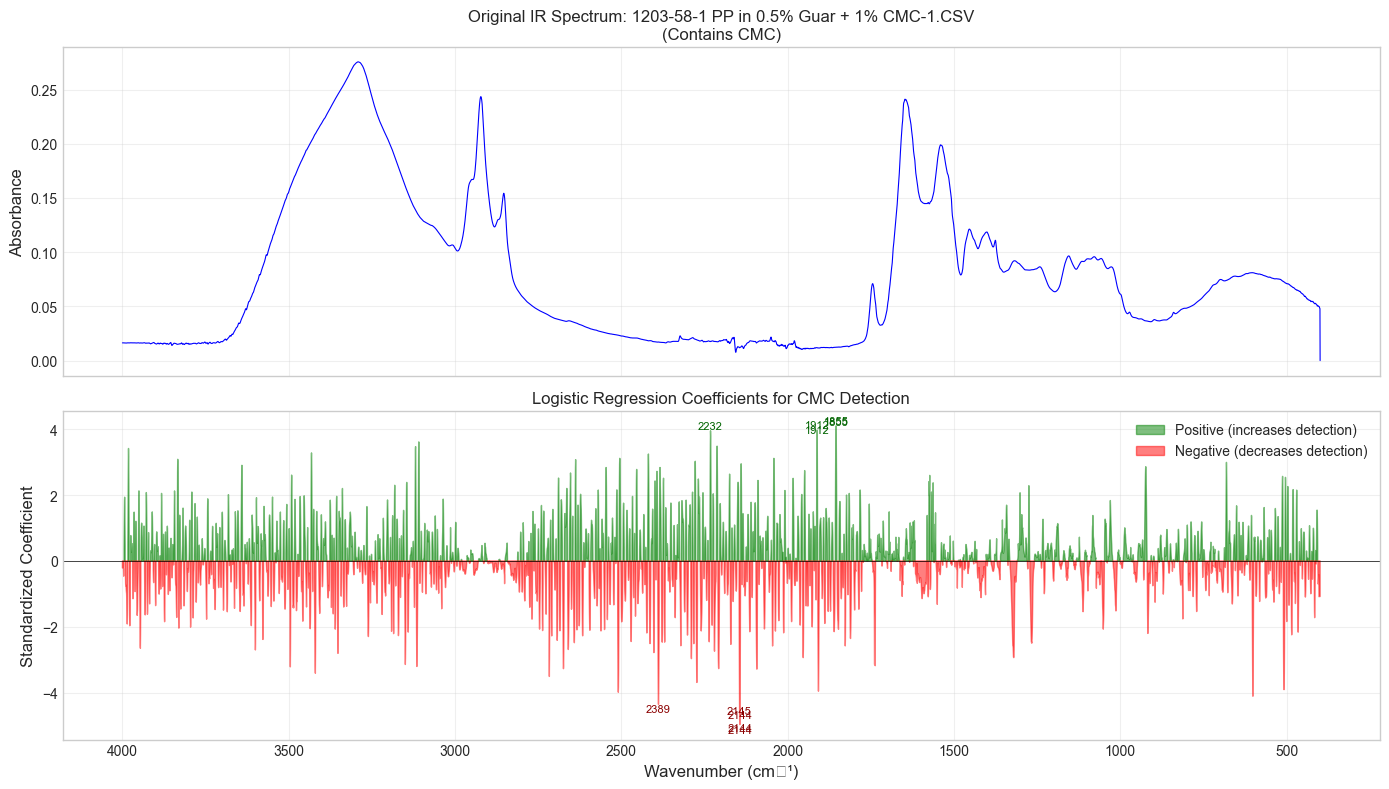


Guar: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


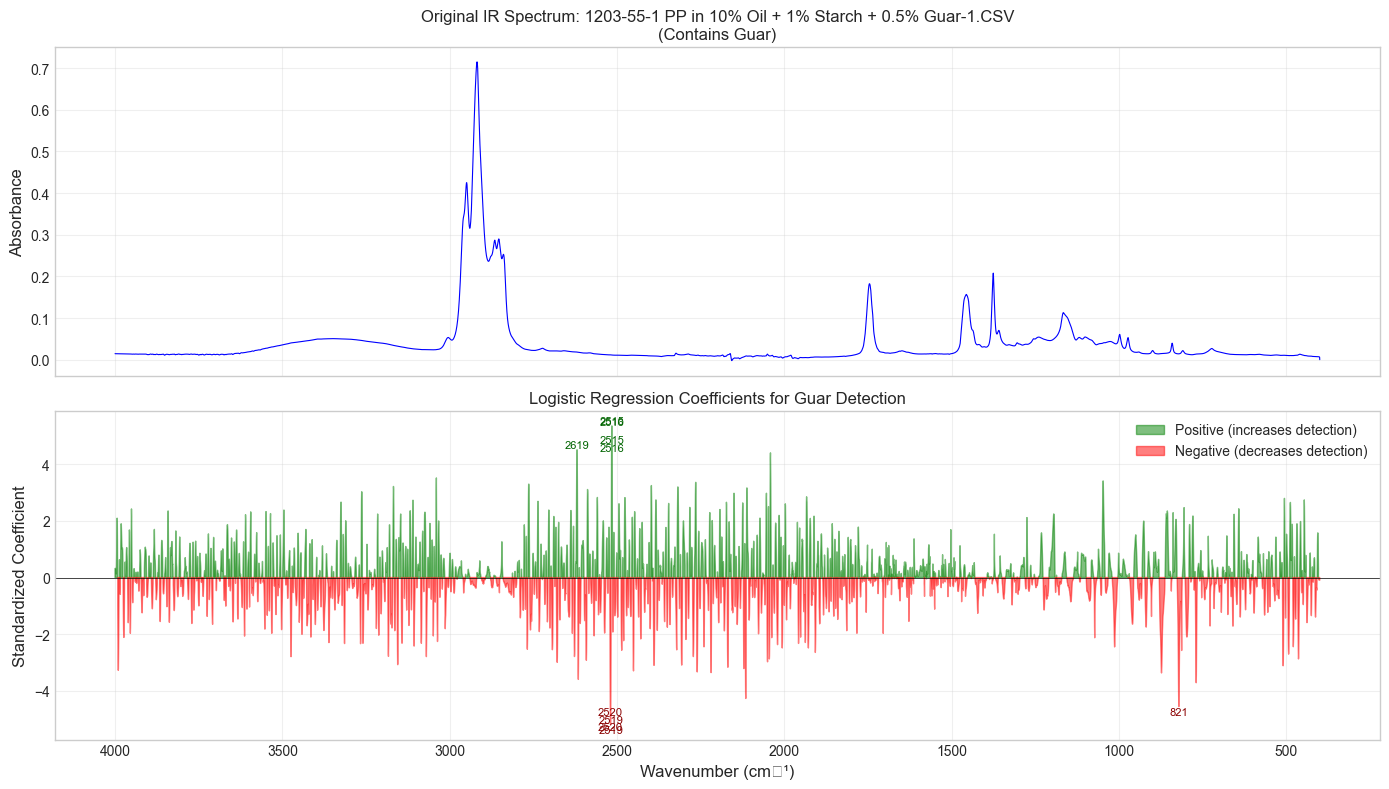


Casein: Using sample 222 (1203-70-1 PP in 4% Casein-1.CSV)


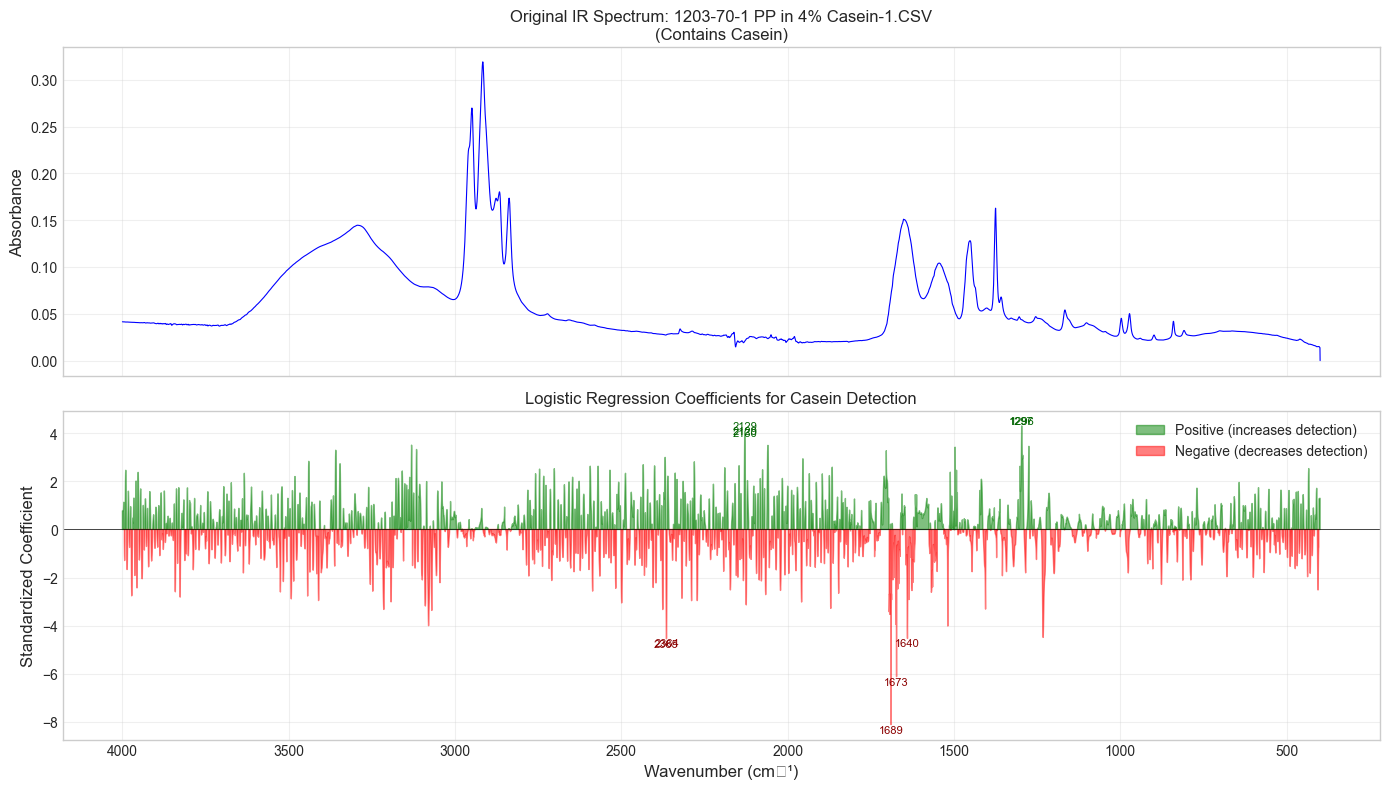

In [39]:
# Compare original spectral signal with standardized coefficients for a contaminant
# This visualization helps understand which spectral features the model uses for detection

def plot_spectrum_vs_coefficients(sample_idx, contaminant_idx, figsize=(14, 8)):
    """
    Create a comparison plot showing:
    - Top: Original IR spectrum of a sample
    - Bottom: Standardized logistic regression coefficients for a contaminant
    
    Parameters:
    -----------
    sample_idx : int
        Index of the sample in the dataset
    contaminant_idx : int
        Index of the contaminant (0=BSA, 1=Oil, 2=Starch, 3=CMC, 4=Guar, 5=Casein)
    """
    contaminant_name = CONTAMINANTS[contaminant_idx]
    
    # Get original spectrum (before second derivative)
    original_spectrum = spectra[sample_idx]
    
    # Get standardized coefficients for this contaminant
    raw_coef = lr_contaminant.estimators_[contaminant_idx].coef_[0]
    
    # Standardize coefficients (z-score normalization)
    coef_mean = np.mean(raw_coef)
    coef_std = np.std(raw_coef)
    standardized_coef = (raw_coef - coef_mean) / coef_std
    
    # Check if this sample contains the contaminant
    has_contaminant = contaminant_labels[sample_idx, contaminant_idx] == 1
    contaminant_status = "Contains" if has_contaminant else "Does not contain"
    
    # Create figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Plot 1: Original IR spectrum
    axes[0].plot(wavenumbers, original_spectrum, linewidth=0.8, color='blue')
    axes[0].set_ylabel('Absorbance', fontsize=12)
    axes[0].set_title(f'Original IR Spectrum: {filenames[sample_idx]}\n({contaminant_status} {contaminant_name})', 
                      fontsize=12)
    axes[0].invert_xaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Standardized coefficients
    # Color positive coefficients (increase probability) differently from negative
    colors = np.where(standardized_coef >= 0, 'green', 'red')
    axes[1].fill_between(wavenumbers, 0, standardized_coef, 
                         where=standardized_coef >= 0, color='green', alpha=0.5, label='Positive (increases detection)')
    axes[1].fill_between(wavenumbers, 0, standardized_coef, 
                         where=standardized_coef < 0, color='red', alpha=0.5, label='Negative (decreases detection)')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Wavenumber (cm⁻¹)', fontsize=12)
    axes[1].set_ylabel('Standardized Coefficient', fontsize=12)
    axes[1].set_title(f'Logistic Regression Coefficients for {contaminant_name} Detection', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # Mark top 5 most positive and negative coefficients
    n_peaks = 5
    top_pos_idx = np.argsort(standardized_coef)[-n_peaks:]
    top_neg_idx = np.argsort(standardized_coef)[:n_peaks]
    
    for idx in top_pos_idx:
        axes[1].annotate(f'{wavenumbers[idx]:.0f}', 
                        xy=(wavenumbers[idx], standardized_coef[idx]),
                        fontsize=8, ha='center', va='bottom', color='darkgreen')
    
    for idx in top_neg_idx:
        axes[1].annotate(f'{wavenumbers[idx]:.0f}', 
                        xy=(wavenumbers[idx], standardized_coef[idx]),
                        fontsize=8, ha='center', va='top', color='darkred')
    
    plt.tight_layout()
    return fig

# Find samples for each contaminant
print("=" * 60)
print("ORIGINAL SPECTRUM vs STANDARDIZED COEFFICIENTS COMPARISON")
print("=" * 60)

# Plot comparison for each contaminant using a sample that contains it
for cont_idx, cont_name in enumerate(CONTAMINANTS):
    # Find a sample that contains this contaminant
    samples_with_cont = np.where(contaminant_labels[:, cont_idx] == 1)[0]
    if len(samples_with_cont) > 0:
        sample_idx = samples_with_cont[0]  # Use first sample with this contaminant
        print(f"\n{cont_name}: Using sample {sample_idx} ({filenames[sample_idx]})")
        fig = plot_spectrum_vs_coefficients(sample_idx, cont_idx)
        plt.savefig(project_root / 'reports' / 'figures' / f'lr_spectrum_vs_coef_{cont_name}.png', dpi=150)
        plt.show()
    else:
        print(f"\n{cont_name}: No samples found with this contaminant")

ORIGINAL SPECTRUM vs STANDARDIZED COEFFICIENTS COMPARISON

BSA: Using sample 28 (1203-56-1 PP in 10% Oil + 16% BSA + 0.5% Guar-1.CSV)


C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3753584423.py:74: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_20340\3753584423.py:90: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / f'lr_spectrum_vs_coef_{cont_name}.png', dpi=150)


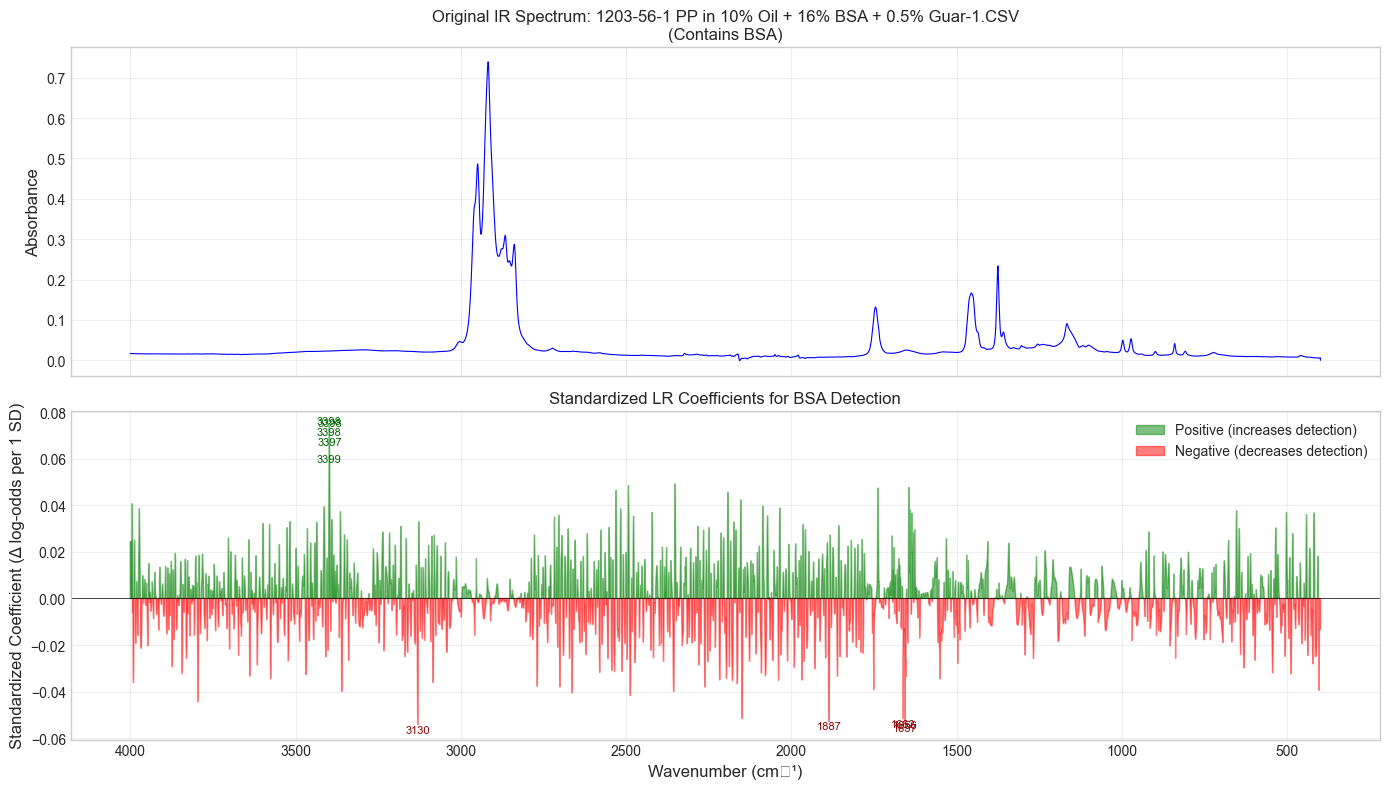


Oil: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


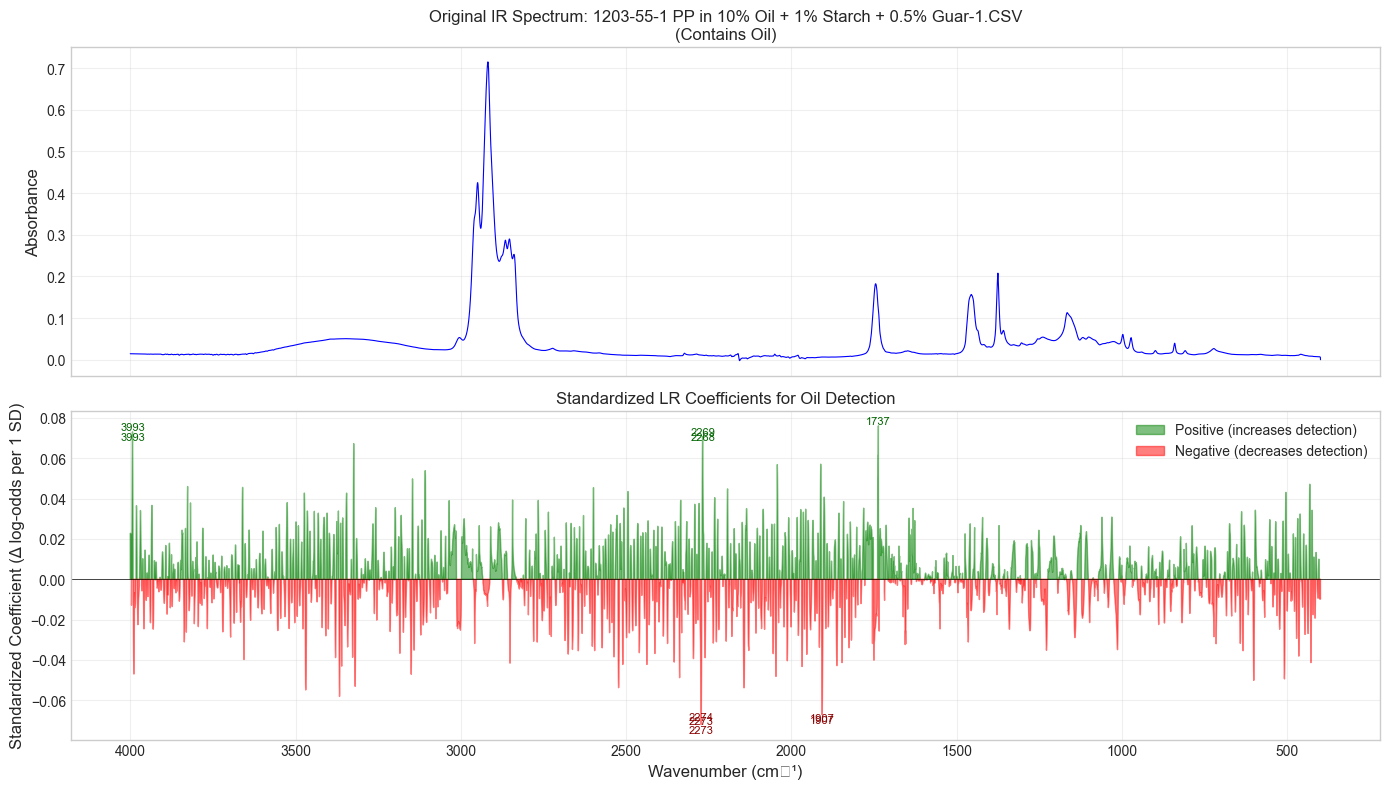


Starch: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


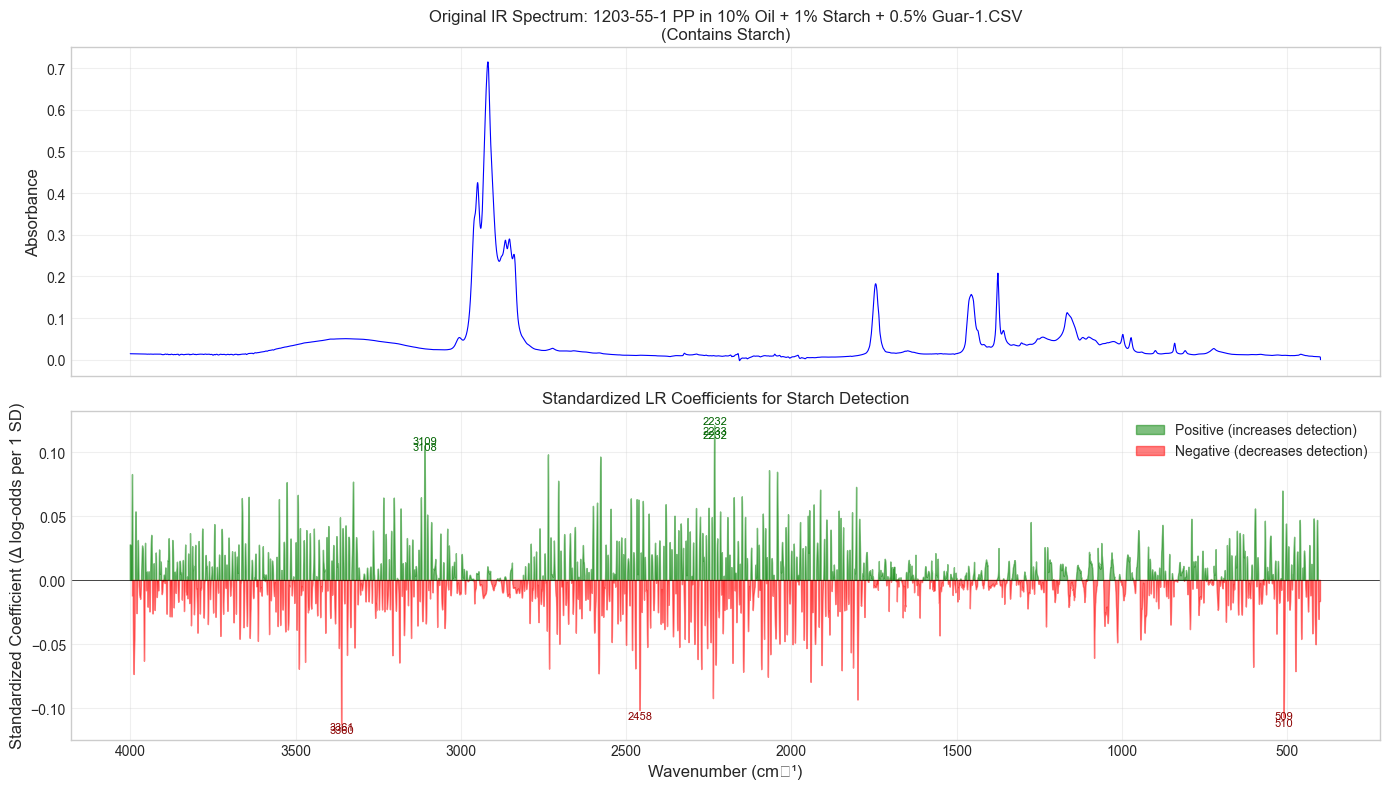


CMC: Using sample 56 (1203-58-1 PP in 0.5% Guar + 1% CMC-1.CSV)


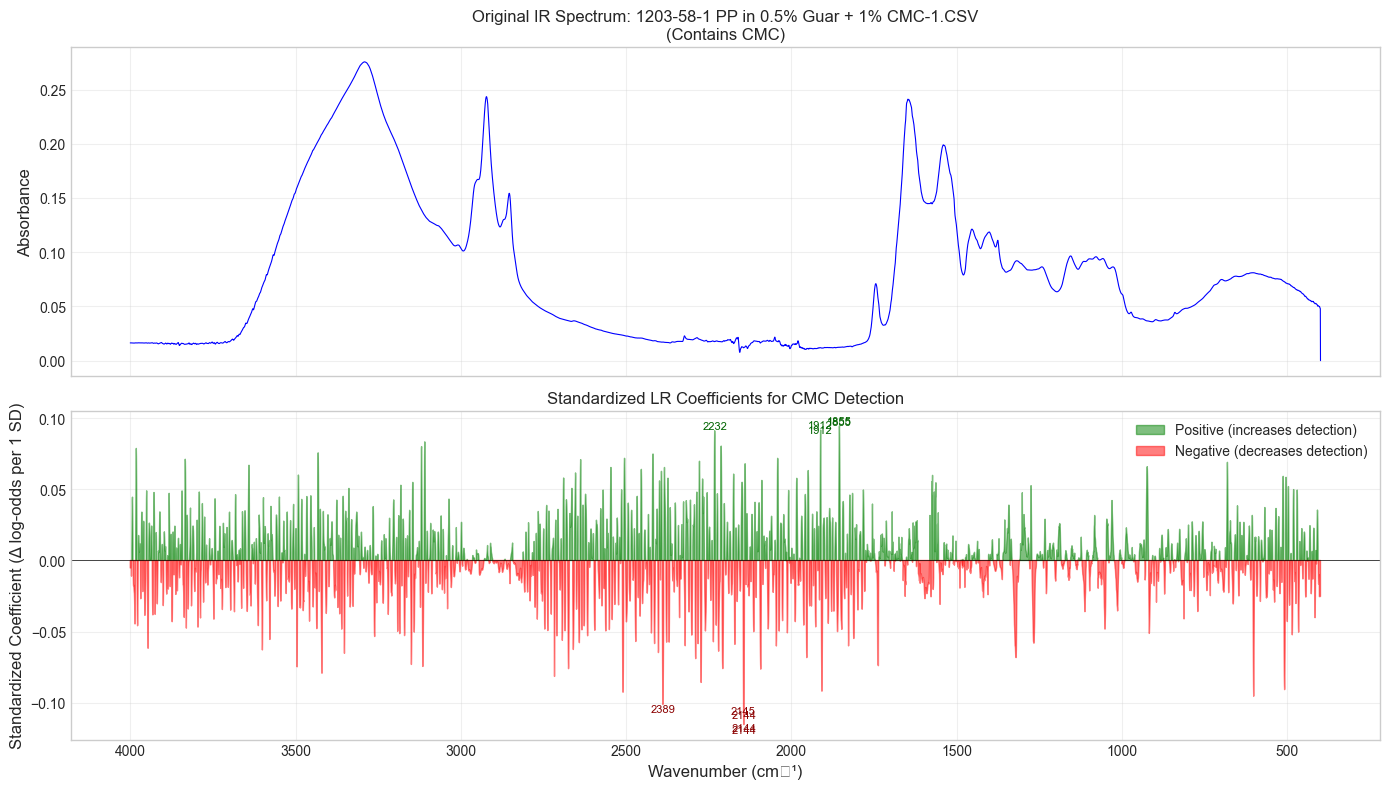


Guar: Using sample 14 (1203-55-1 PP in 10% Oil + 1% Starch + 0.5% Guar-1.CSV)


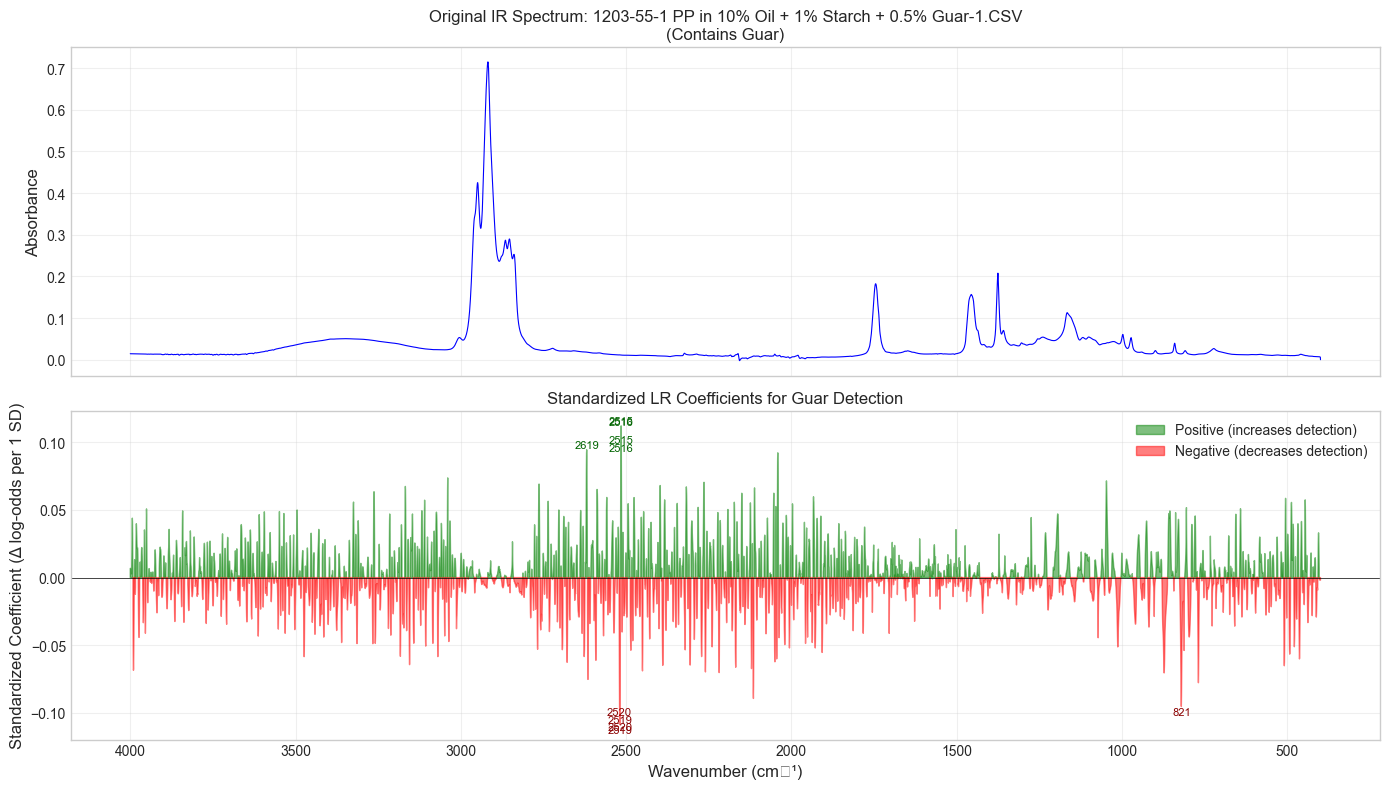


Casein: Using sample 222 (1203-70-1 PP in 4% Casein-1.CSV)


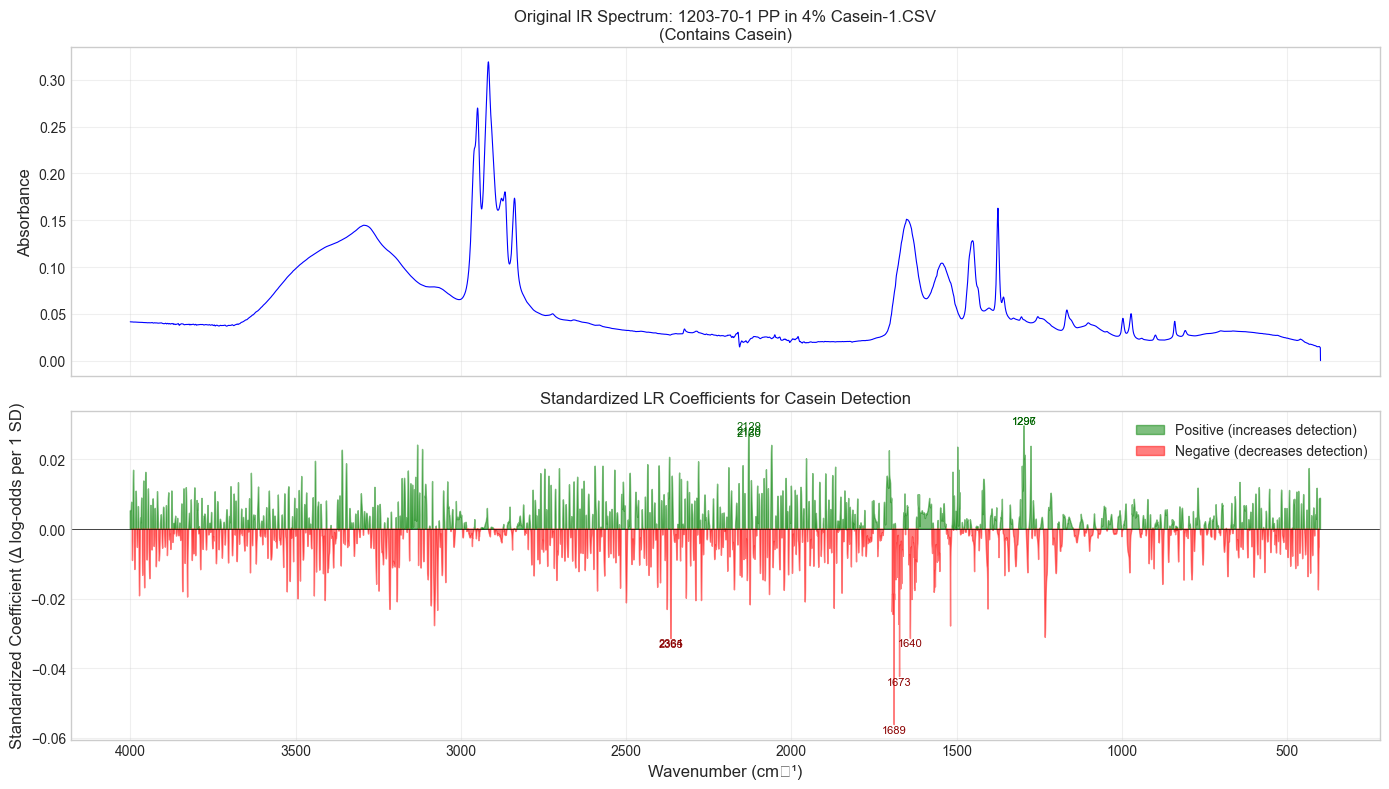

In [40]:
# Compare original spectral signal with standardized coefficients for a contaminant
# Since the model was trained on StandardScaler-transformed data, the raw coefficients
# are already standardized: each represents the change in log-odds per 1 SD change in the feature.

def plot_spectrum_vs_coefficients(sample_idx, contaminant_idx, figsize=(14, 8)):
    """
    Create a comparison plot showing:
    - Top: Original IR spectrum of a sample
    - Bottom: Standardized logistic regression coefficients for a contaminant
    
    Because the model was fit on StandardScaler-transformed data,
    the raw model coefficients are already standardized coefficients
    (change in log-odds per 1 standard deviation change in feature).
    
    Parameters:
    -----------
    sample_idx : int
        Index of the sample in the dataset
    contaminant_idx : int
        Index of the contaminant (0=BSA, 1=Oil, 2=Starch, 3=CMC, 4=Guar, 5=Casein)
    """
    contaminant_name = CONTAMINANTS[contaminant_idx]
    
    # Get original spectrum (before second derivative)
    original_spectrum = spectra[sample_idx]
    
    # Get standardized coefficients for this contaminant
    # These are already standardized because the model was trained on StandardScaler-transformed data
    standardized_coef = lr_contaminant.estimators_[contaminant_idx].coef_[0]
    
    # Check if this sample contains the contaminant
    has_contaminant = contaminant_labels[sample_idx, contaminant_idx] == 1
    contaminant_status = "Contains" if has_contaminant else "Does not contain"
    
    # Create figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Plot 1: Original IR spectrum
    axes[0].plot(wavenumbers, original_spectrum, linewidth=0.8, color='blue')
    axes[0].set_ylabel('Absorbance', fontsize=12)
    axes[0].set_title(f'Original IR Spectrum: {filenames[sample_idx]}\n({contaminant_status} {contaminant_name})', 
                      fontsize=12)
    axes[0].invert_xaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Standardized coefficients
    # Color positive coefficients (increase probability) differently from negative
    axes[1].fill_between(wavenumbers, 0, standardized_coef, 
                         where=standardized_coef >= 0, color='green', alpha=0.5, label='Positive (increases detection)')
    axes[1].fill_between(wavenumbers, 0, standardized_coef, 
                         where=standardized_coef < 0, color='red', alpha=0.5, label='Negative (decreases detection)')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Wavenumber (cm⁻¹)', fontsize=12)
    axes[1].set_ylabel('Standardized Coefficient (Δ log-odds per 1 SD)', fontsize=12)
    axes[1].set_title(f'Standardized LR Coefficients for {contaminant_name} Detection', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # Mark top 5 most positive and negative coefficients
    n_peaks = 5
    top_pos_idx = np.argsort(standardized_coef)[-n_peaks:]
    top_neg_idx = np.argsort(standardized_coef)[:n_peaks]
    
    for idx in top_pos_idx:
        axes[1].annotate(f'{wavenumbers[idx]:.0f}', 
                        xy=(wavenumbers[idx], standardized_coef[idx]),
                        fontsize=8, ha='center', va='bottom', color='darkgreen')
    
    for idx in top_neg_idx:
        axes[1].annotate(f'{wavenumbers[idx]:.0f}', 
                        xy=(wavenumbers[idx], standardized_coef[idx]),
                        fontsize=8, ha='center', va='top', color='darkred')
    
    plt.tight_layout()
    return fig

# Find samples for each contaminant
print("=" * 60)
print("ORIGINAL SPECTRUM vs STANDARDIZED COEFFICIENTS COMPARISON")
print("=" * 60)

# Plot comparison for each contaminant using a sample that contains it
for cont_idx, cont_name in enumerate(CONTAMINANTS):
    # Find a sample that contains this contaminant
    samples_with_cont = np.where(contaminant_labels[:, cont_idx] == 1)[0]
    if len(samples_with_cont) > 0:
        sample_idx = samples_with_cont[0]  # Use first sample with this contaminant
        print(f"\n{cont_name}: Using sample {sample_idx} ({filenames[sample_idx]})")
        fig = plot_spectrum_vs_coefficients(sample_idx, cont_idx)
        plt.savefig(project_root / 'reports' / 'figures' / f'lr_spectrum_vs_coef_{cont_name}.png', dpi=150)
        plt.show()
    else:
        print(f"\n{cont_name}: No samples found with this contaminant")

In [44]:
# Sensitivity analysis: effect of random seed on final combined model metrics
# This reruns the Section 5 workflow with different train/test split + model seeds
# and summarizes key performance metrics in a table.


seed_values = list(range(1, 501, 20))  
seed_results = []

print("=" * 80)
print("RANDOM SEED SENSITIVITY ANALYSIS - FINAL COMBINED MODEL")
print("=" * 80)

for seed in seed_values:
    # 1) Split using current seed (same strategy as main pipeline)
    X_train_seed, X_test_seed, y_plastic_train_seed, y_plastic_test_seed, y_contaminant_train_seed, y_contaminant_test_seed = train_test_split(
        X,
        y_plastic,
        y_contaminant,
        test_size=0.2,
        random_state=seed,
        stratify=y_plastic
    )

    # 2) Scale features using training-only statistics
    scaler_seed = StandardScaler()
    X_train_seed_scaled = scaler_seed.fit_transform(X_train_seed)
    X_test_seed_scaled = scaler_seed.transform(X_test_seed)

    # 3) Build combined labels
    y_combined_train_seed = np.column_stack([y_plastic_train_seed.reshape(-1, 1), y_contaminant_train_seed])
    y_combined_test_seed = np.column_stack([y_plastic_test_seed.reshape(-1, 1), y_contaminant_test_seed])

    # 4) Train final combined model
    base_lr_seed = LogisticRegression(
        solver='newton-cg',
        max_iter=5000,
        random_state=seed,
        C=10.0
    )
    lr_combined_seed = MultiOutputClassifier(base_lr_seed, n_jobs=-1)
    lr_combined_seed.fit(X_train_seed_scaled, y_combined_train_seed)

    # 5) Evaluate key metrics
    y_combined_pred_seed = lr_combined_seed.predict(X_test_seed_scaled)

    plastic_acc_seed = accuracy_score(y_combined_test_seed[:, 0], y_combined_pred_seed[:, 0])
    contaminant_hamming_seed = hamming_loss(y_combined_test_seed[:, 1:], y_combined_pred_seed[:, 1:])
    overall_exact_match_seed = np.all(y_combined_test_seed == y_combined_pred_seed, axis=1).mean()

    seed_results.append({
        'Seed': seed,
        'Plastic Accuracy (%)': plastic_acc_seed * 100,
        'Contaminant Hamming Loss (%)': contaminant_hamming_seed * 100,
        'Overall Exact Match (%)': overall_exact_match_seed * 100
    })

# Create result table
seed_metrics_df = pd.DataFrame(seed_results)
seed_metrics_df = seed_metrics_df.sort_values('Seed').reset_index(drop=True)

# Add summary statistics table
summary_df = pd.DataFrame({
    'Metric': ['Plastic Accuracy (%)', 'Contaminant Hamming Loss (%)', 'Overall Exact Match (%)'],
    'Mean': [
        seed_metrics_df['Plastic Accuracy (%)'].mean(),
        seed_metrics_df['Contaminant Hamming Loss (%)'].mean(),
        seed_metrics_df['Overall Exact Match (%)'].mean()
    ],
    'Std Dev': [
        seed_metrics_df['Plastic Accuracy (%)'].std(),
        seed_metrics_df['Contaminant Hamming Loss (%)'].std(),
        seed_metrics_df['Overall Exact Match (%)'].std()
    ],
    'Min': [
        seed_metrics_df['Plastic Accuracy (%)'].min(),
        seed_metrics_df['Contaminant Hamming Loss (%)'].min(),
        seed_metrics_df['Overall Exact Match (%)'].min()
    ],
    'Max': [
        seed_metrics_df['Plastic Accuracy (%)'].max(),
        seed_metrics_df['Contaminant Hamming Loss (%)'].max(),
        seed_metrics_df['Overall Exact Match (%)'].max()
    ]
})

print("\nPer-seed metrics table:")
display(seed_metrics_df.style.format({
    'Plastic Accuracy (%)': '{:.2f}',
    'Contaminant Hamming Loss (%)': '{:.2f}',
    'Overall Exact Match (%)': '{:.2f}'
}))

print("\nSummary statistics across seeds:")
display(summary_df.style.format({
    'Mean': '{:.2f}',
    'Std Dev': '{:.2f}',
    'Min': '{:.2f}',
    'Max': '{:.2f}'
}))

# Optional: save results table
seed_table_path = project_root / 'reports' / 'text_reports' / 'lr_second_derivative_seed_sensitivity_metrics.csv'
seed_metrics_df.to_csv(seed_table_path, index=False)
print(f"\nSaved per-seed metrics to: {seed_table_path}")

RANDOM SEED SENSITIVITY ANALYSIS - FINAL COMBINED MODEL

Per-seed metrics table:


,Seed,Plastic Accuracy (%),Contaminant Hamming Loss (%),Overall Exact Match (%)
0,1,96.20,0.53,94.30
1,21,97.47,0.21,96.20
2,41,92.41,0.84,89.87
3,61,97.47,0.74,95.57
4,81,97.47,1.05,94.94
5,101,96.20,0.00,96.20
6,121,92.41,0.21,91.14
7,141,100.00,0.21,98.73
8,161,100.00,1.69,94.94
9,181,94.94,0.21,93.67



Summary statistics across seeds:


,Metric,Mean,Std Dev,Min,Max
0,Plastic Accuracy (%),96.15,2.27,91.14,100.00
1,Contaminant Hamming Loss (%),0.53,0.44,0.00,1.69
2,Overall Exact Match (%),94.68,2.37,89.24,98.73



Saved per-seed metrics to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports\lr_second_derivative_seed_sensitivity_metrics.csv
